# Agent Liquidity Forecaster: EDA, Modeling and Impact Analysis
**DIU CPC × upay AI Hackathon 2026**

**Problem.** An upay agent holds two balances, physical **cash** and digital **e-float**. Every cash-out moves value from cash to e-float, every cash-in does the opposite, and a customer who arrives when either balance is empty goes unserved. We forecast demand for the next 7 days and convert it into the five outputs the app needs:

| # | App output | How it is produced |
|---|---|---|
| 1 | % chance **cash runs out** | Monte Carlo roll-forward of the demand forecast |
| 2 | % chance **e-float runs out** | same engine, opposite direction |
| 3 | **Chance / distribution** of cash-in and cash-out per day | LightGBM quantile models (P10 to P90) + surge probability |
| 4 | **Expected amount** of cash-in / cash-out per day | median and mean of the predicted distribution |
| 5 | **Recommended inventory** to hold | business rule on top of the forecast (kept *outside* the ML model) |

**Roadmap:** data integrity → EDA → problem framing → features → baselines → model → evaluation → explainability → stress tests → risk engine → policy replay (business impact) → export `.pkl`.

> **Notebook rule:** every claim is backed by a printed number or plot in this notebook. Where something does *not* work well, it is reported as such.

In [1]:
import warnings, time, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 12, "axes.titleweight": "bold", "figure.autolayout": True})
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 60

SEED = 42
SUMMARY = {}                      # key results collected along the way, stored in the .pkl at the end
CANDIDATES = [Path("agent_liquidity_dataset_v2.csv"), Path("/mnt/user-data/outputs/agent_liquidity_dataset_v2.csv")]
DATA_PATH = next(p for p in CANDIDATES if p.exists())
AGENTS_PATH = DATA_PATH.with_name("agents_metadata.csv")
print("dataset:", DATA_PATH)

dataset: agent_liquidity_dataset_v2.csv


## 1. Shared module

Training, evaluation and the future FastAPI backend must all build features **the same way**. If training features and serving features drift apart, the model silently degrades. So the reusable logic (calendar, feature builder, quantile prediction, Monte Carlo risk engine, explanation helper) lives in one module, written out by the next cell. The cell below it imports it.

In [2]:
%%writefile liquidity_forecaster.py
"""
liquidity_forecaster.py
Agent Liquidity Forecaster - shared logic for training, evaluation and serving.
DIU CPC x upay AI Hackathon 2026

Pipeline:  daily history -> make_features -> quantile models -> Monte Carlo roll-forward -> risk + recommendation
Design rules (from the rulebook):
  * data preparation is separate from model inference
  * business rules (buffers, coverage probability) live in `risk_config`, NOT inside the ML model
  * every output is traceable to a model quantile or a documented rule
"""
import numpy as np
import pandas as pd
from datetime import date, timedelta

H = 7                                   # forecast horizon (days)
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
MIN_HIST = 28                           # days of history needed at the forecast origin

CAL_COLS = ["day_of_week", "day_of_month", "month", "days_to_month_end", "is_weekend", "is_friday",
            "is_holiday", "is_working_day", "closed_days_ahead", "is_eid_day", "is_pre_eid_fitr",
            "is_pre_eid_adha", "is_eid_bonus_week", "days_to_nearest_eid", "is_ramadan",
            "is_salary_week", "is_post_salary_week", "is_month_end_week", "is_semester_start"]
TRAIT_COLS = ["urban", "garment", "remittance", "agri", "university"]

# Interaction features (agent type x calendar event). Payday, bonus and semester effects apply to ONE kind of
# agent only; rare, type-specific effects are hard for trees to discover from ~200 rows, so we cross them explicitly.
CROSS_EVENTS = ["is_salary_week", "is_post_salary_week", "is_month_end_week", "is_eid_bonus_week",
                "pre_eid_any", "is_semester_start", "is_ramadan"]
CROSS_COLS = [f"x_{t}_{e}" for e in CROSS_EVENTS for t in TRAIT_COLS]

DEFAULT_RISK_CONFIG = dict(
    buffer_frac=0.10,        # "effectively out" = balance below 10% of capacity
    coverage_prob=0.95,      # recommended level protects the window with 95% probability
    n_paths=2000,            # Monte Carlo paths
    surge_multiple=1.5,      # a "surge day" = demand > 1.5x the agent's 28-day mean
    min_order_frac=0.10,     # ignore top-ups smaller than 10% of capacity (not worth a trip)
)

# Official 2025 calendar used by the dataset (moon-dependent dates may shift +/-1 day).
DEFAULT_CALENDAR_CONFIG = dict(
    holidays=["2025-02-21", "2025-03-26", "2025-04-14", "2025-05-01", "2025-07-06", "2025-08-16",
              "2025-10-01", "2025-10-02", "2025-12-16", "2025-12-25"],
    holiday_windows=[("2025-03-29", "2025-04-02"), ("2025-06-05", "2025-06-10")],   # Eid holidays
    eid_fitr="2025-03-31", eid_adha="2025-06-07",
    ramadan=("2025-03-02", "2025-03-30"),
)


# ------------------------------------------------------------------ calendar --
def build_calendar(dates, cfg=None):
    """Calendar features for any list of dates. Used at serving time for FUTURE dates,
    where the dataset has no rows yet. Must reproduce the training calendar exactly."""
    cfg = cfg or DEFAULT_CALENDAR_CONFIG
    c = pd.DataFrame({"date": pd.to_datetime(list(dates))})
    hol = {pd.Timestamp(d).date() for d in cfg["holidays"]}
    for a, b in cfg["holiday_windows"]:
        a, b = pd.Timestamp(a), pd.Timestamp(b)
        hol |= {(a + timedelta(i)).date() for i in range((b - a).days + 1)}
    fitr, adha = pd.Timestamp(cfg["eid_fitr"]), pd.Timestamp(cfg["eid_adha"])
    c["day_of_week"] = c.date.dt.dayofweek
    c["day_of_month"] = c.date.dt.day
    c["month"] = c.date.dt.month
    c["days_to_month_end"] = (c.date + pd.offsets.MonthEnd(0) - c.date).dt.days
    c["is_friday"] = (c.day_of_week == 4).astype(int)
    c["is_weekend"] = c.day_of_week.isin([4, 5]).astype(int)
    c["is_holiday"] = c.date.dt.date.isin(hol).astype(int)
    c["is_working_day"] = ((c.is_weekend == 0) & (c.is_holiday == 0)).astype(int)
    c["is_salary_week"] = c.day_of_month.between(7, 10).astype(int)
    c["is_post_salary_week"] = c.day_of_month.between(11, 16).astype(int)
    c["is_month_end_week"] = (c.days_to_month_end <= 5).astype(int)
    d_f, d_a = (fitr - c.date).dt.days, (adha - c.date).dt.days
    c["days_to_nearest_eid"] = np.where(d_f.abs() <= d_a.abs(), d_f, d_a).clip(-30, 30)
    c["is_pre_eid_fitr"] = d_f.between(3, 9).astype(int)
    c["is_pre_eid_adha"] = d_a.between(3, 9).astype(int)
    c["is_eid_day"] = (d_f.between(-1, 0) | d_a.between(-1, 0)).astype(int)
    c["is_eid_bonus_week"] = (d_f.between(10, 19) | d_a.between(10, 19)).astype(int)
    c["is_ramadan"] = c.date.between(*cfg["ramadan"]).astype(int)
    c["is_semester_start"] = (((c.month == 2) & (c.day_of_month <= 15)) |
                              ((c.month == 7) & (c.day_of_month <= 15))).astype(int)
    wd, n = c.is_working_day.values, len(c)
    closed = np.zeros(n, int)
    for i in range(n):
        k = 1
        while i + k < n and wd[i + k] == 0:
            k += 1
        closed[i] = k - 1 if i + k < n else 0
    c["closed_days_ahead"] = closed
    return c


# ---------------------------------------------------------------- features ---
def _prefix(x):
    return np.concatenate([[0.0], np.cumsum(np.nan_to_num(x))])


def make_features(df, origins=None, h_max=H, min_hist=MIN_HIST):
    """Direct multi-horizon feature builder.

    One output row = one (agent, forecast origin t, horizon h) triple, predicting day d = t + h.
    LEAKAGE RULE: only information available at the END of day t may be used for history
    features (obs[<= t]); calendar features of day d are legitimately known in advance.
    The demand model deliberately ignores the agent's current balances, so it forecasts
    DEMAND, not the agent's own supply decisions. Balances are used later, in the roll-forward.

    df: one row per agent-date (sorted by date), must contain calendar columns for the target dates.
        Future rows (date > origin) may have NaN flows.
    origins: optional set of dates to forecast from; default = every date with enough history
             and a full horizon of future rows.
    """
    rows = []
    origins = None if origins is None else {pd.Timestamp(o) for o in origins}
    for aid, g in df.groupby("agent_id", sort=False):
        g = g.sort_values("date").reset_index(drop=True)
        n = len(g)
        dates = pd.to_datetime(g["date"])
        co, ci = g["observed_cashout"].to_numpy(float), g["observed_cashin"].to_numpy(float)
        tco = g["true_cashout_demand"].to_numpy(float) if "true_cashout_demand" in g else np.full(n, np.nan)
        tci = g["true_cashin_demand"].to_numpy(float) if "true_cashin_demand" in g else np.full(n, np.nan)
        cc = g["closing_cash"].to_numpy(float) if "closing_cash" in g else np.full(n, np.nan)
        ce = g["closing_efloat"].to_numpy(float) if "closing_efloat" in g else np.full(n, np.nan)
        P = {"co": _prefix(co), "ci": _prefix(ci)}
        X = {"co": co, "ci": ci}
        if origins is None:
            t_idx = np.arange(min_hist - 1, n - h_max)
        else:
            t_idx = np.array([i for i in range(n) if dates[i] in origins and i >= min_hist - 1 and i + h_max < n])
        if len(t_idx) == 0:
            continue
        # origin-level quantities
        base = {}
        for p in ("co", "ci"):
            scale = (P[p][t_idx + 1] - P[p][t_idx - 27]) / 28.0
            scale = np.maximum(scale, 1.0)
            base[f"{p}_scale"] = scale
            base[f"{p}_logscale"] = np.log(scale)
            base[f"{p}_last_r"] = X[p][t_idx] / scale
            base[f"{p}_roll7_r"] = ((P[p][t_idx + 1] - P[p][t_idx - 6]) / 7.0) / scale
        base["log_co_ci_scale"] = base["co_logscale"] - base["ci_logscale"]
        cal = g[CAL_COLS].to_numpy()
        traits = g.loc[0, TRAIT_COLS].to_numpy(float)
        logcap = np.log(g.loc[0, ["agent_capacity_cash", "agent_capacity_efloat"]].to_numpy(float))
        for h in range(1, h_max + 1):
            d = t_idx + h
            r = {"agent_id": np.repeat(aid, len(t_idx)),
                 "origin_date": dates.values[t_idx], "target_date": dates.values[d], "h": np.full(len(t_idx), h)}
            r.update(base)
            for p in ("co", "ci"):
                s = base[f"{p}_scale"]
                l7, l14, l21 = X[p][d - 7], X[p][d - 14], X[p][d - 21]
                r[f"{p}_lag7_r"], r[f"{p}_lag14_r"], r[f"{p}_lag21_r"] = l7 / s, l14 / s, l21 / s
                r[f"{p}_dowmean_r"] = np.nanmean(np.stack([l7, l14, l21]), axis=0) / s
            for j, name in enumerate(CAL_COLS):
                r[name] = cal[d, j]
            for j, name in enumerate(TRAIT_COLS):
                r[name] = np.full(len(t_idx), traits[j])
            r["logcap_cash"], r["logcap_ef"] = np.full(len(t_idx), logcap[0]), np.full(len(t_idx), logcap[1])
            r["pre_eid_any"] = ((r["is_pre_eid_fitr"] + r["is_pre_eid_adha"]) > 0).astype(int)
            for e in CROSS_EVENTS:
                for j, tname in enumerate(TRAIT_COLS):
                    r[f"x_{tname}_{e}"] = traits[j] * r[e]
            # targets (NaN at serving time)
            r["y_co"], r["y_ci"], r["yt_co"], r["yt_ci"] = co[d], ci[d], tco[d], tci[d]
            # state at origin (used by the roll-forward, not by the demand model)
            r["cash0"], r["ef0"] = cc[t_idx], ce[t_idx]
            r["closed_ahead_origin"] = g["closed_days_ahead"].to_numpy()[t_idx]
            r["cap_cash"], r["cap_ef"] = np.full(len(t_idx), np.exp(logcap[0])), np.full(len(t_idx), np.exp(logcap[1]))
            rows.append(pd.DataFrame(r))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


BASE_FEATURE_COLS = (["h"] + CAL_COLS + TRAIT_COLS + ["logcap_cash", "logcap_ef", "log_co_ci_scale"] +
                     [f"{p}_{s}" for p in ("co", "ci")
                      for s in ("logscale", "last_r", "roll7_r", "lag7_r", "lag14_r", "lag21_r", "dowmean_r")])
FEATURE_COLS = BASE_FEATURE_COLS + CROSS_COLS


# -------------------------------------------------------------- prediction ---
def predict_quantiles(bundle, feats):
    """Returns {'co': (N, n_q), 'ci': (N, n_q)} in currency units (BDT), non-crossing, >= 0."""
    out = {}
    cols = bundle["feature_cols"]
    for flow in ("co", "ci"):
        P = np.column_stack([bundle["models"][flow][q].predict(feats[cols]) for q in bundle["quantiles"]])
        P = np.sort(P, axis=1) * feats[f"{flow}_scale"].to_numpy()[:, None]
        out[flow] = np.maximum(P, 0.0)
    return out


# --------------------------------------------------------- Monte Carlo risk ---
def _inverse_cdf(qs, q_levels, u):
    """Piecewise-linear inverse CDF through the predicted quantiles.
    Tails beyond q10/q90 are extrapolated (assumption, documented in the notebook)."""
    lo = max(0.0, qs[0] - 0.75 * (qs[2] - qs[0]))
    hi = qs[-1] + 0.75 * (qs[-1] - qs[2])
    return np.interp(u, np.concatenate([[0.0], q_levels, [1.0]]), np.concatenate([[lo], qs, [hi]]))


def sample_flows(q_co, q_ci, q_levels, n_paths, rng):
    """q_co, q_ci: (H, n_q) quantile forecasts for one agent at one origin.
    Days and flows are sampled independently (simplifying assumption)."""
    Hh = q_co.shape[0]
    co = np.column_stack([_inverse_cdf(q_co[k], q_levels, rng.random(n_paths)) for k in range(Hh)])
    ci = np.column_stack([_inverse_cdf(q_ci[k], q_levels, rng.random(n_paths)) for k in range(Hh)])
    return co, ci


def risk_summary(q_co, q_ci, q_levels, cash0, ef0, cap_cash, cap_ef, closed_ahead, scale_co, scale_ci,
                 cfg=None, rng=None, extra_coverage=()):
    """Turns the demand distribution into the five app outputs for one agent at one origin."""
    cfg = {**DEFAULT_RISK_CONFIG, **(cfg or {})}
    rng = rng or np.random.default_rng(0)
    co, ci = sample_flows(q_co, q_ci, q_levels, cfg["n_paths"], rng)
    net = co - ci                                   # >0 drains cash, raises e-float
    cum = np.cumsum(net, axis=1)
    buf_c, buf_e = cfg["buffer_frac"] * cap_cash, cfg["buffer_frac"] * cap_ef
    cash_path, ef_path = cash0 - cum, ef0 + cum
    cash_breach = np.maximum.accumulate(cash_path < buf_c, axis=1)   # "has run out by day k"
    ef_breach = np.maximum.accumulate(ef_path < buf_e, axis=1)
    risk_cash_by_day, risk_ef_by_day = cash_breach.mean(0), ef_breach.mean(0)

    def first_day(r):
        idx = np.where(r >= 0.5)[0]
        return int(idx[0]) + 1 if len(idx) else None

    # Output 5: recommended holding level. Window = days until a top-up can realistically arrive
    # (closed days ahead + order lead time), capped at the horizon.
    W = int(min(q_co.shape[0], closed_ahead + 2))
    max_out, max_in = cum[:, :W].max(axis=1), (-cum[:, :W]).max(axis=1)   # worst cumulative drain per path
    req_by_cov = {}
    for p in sorted({cfg["coverage_prob"], *extra_coverage}):
        req_by_cov[p] = (max(np.quantile(max_out, p), 0.0) + buf_c, max(np.quantile(max_in, p), 0.0) + buf_e)
    req_cash, req_ef = req_by_cov[cfg["coverage_prob"]]
    topup_cash, topup_ef = max(0.0, req_cash - cash0), max(0.0, req_ef - ef0)
    total = cash0 + ef0
    return dict(
        cash_risk_pct_7d=100 * risk_cash_by_day[-1], efloat_risk_pct_7d=100 * risk_ef_by_day[-1],       # outputs 1, 2
        cash_risk_pct_by_day=100 * risk_cash_by_day, efloat_risk_pct_by_day=100 * risk_ef_by_day,
        likely_cash_runout_day=first_day(risk_cash_by_day), likely_efloat_runout_day=first_day(risk_ef_by_day),
        cashout_q=q_co, cashin_q=q_ci,                                                                    # outputs 3, 4
        expected_cashout=co.mean(0), expected_cashin=ci.mean(0),
        p_cashout_surge=(co > cfg["surge_multiple"] * scale_co).mean(0),
        p_cashin_surge=(ci > cfg["surge_multiple"] * scale_ci).mean(0),
        coverage_window_days=W, recommended_cash_level=req_cash, recommended_efloat_level=req_ef,         # output 5
        topup_cash_needed=topup_cash if topup_cash >= cfg["min_order_frac"] * cap_cash else 0.0,
        topup_efloat_needed=topup_ef if topup_ef >= cfg["min_order_frac"] * cap_ef else 0.0,
        float_insufficient=bool(req_cash + req_ef > total),
        req_by_coverage=req_by_cov,
    )


# ----------------------------------------------------------- serving helper ---
def get_agent_row(bundle, agent_id):
    """Agent traits + capacities in the shape forecast_agent() expects."""
    a = bundle["agents"].set_index("agent_id").loc[agent_id].copy()
    a["agent_id"] = agent_id
    for c in TRAIT_COLS:
        a[c] = int(a[c])
    return a


def forecast_agent(bundle, history, agent_row, origin_date, closing_cash, closing_efloat, seed=0):
    """Serve-time entry point.
    history   : DataFrame[date, observed_cashout, observed_cashin] with >= 28 days up to origin_date
    agent_row : Series with the agent traits and capacities (see bundle['agents'])
    Builds future calendar rows itself, so no future data is required."""
    origin = pd.Timestamp(origin_date)
    hist = history[history["date"] <= origin].copy()
    hist["date"] = pd.to_datetime(hist["date"])
    fut_dates = [origin + timedelta(i) for i in range(1, H + 1)]
    all_dates = list(hist["date"]) + fut_dates
    cal = build_calendar(all_dates + [origin + timedelta(H + 30)], bundle["calendar_config"]).iloc[:len(all_dates)]
    df = cal.copy()
    df["agent_id"] = agent_row["agent_id"]
    for c in TRAIT_COLS:
        df[c] = agent_row[c]
    df["agent_capacity_cash"], df["agent_capacity_efloat"] = agent_row["capacity_cash"], agent_row["capacity_efloat"]
    df["observed_cashout"] = list(hist["observed_cashout"]) + [np.nan] * H
    df["observed_cashin"] = list(hist["observed_cashin"]) + [np.nan] * H
    df["closing_cash"], df["closing_efloat"] = closing_cash, closing_efloat
    f = make_features(df, origins=[origin])
    if f.empty:
        raise ValueError("Need at least 28 days of history ending at the origin date.")
    q = predict_quantiles(bundle, f)
    r = f.iloc[0]
    return risk_summary(q["co"], q["ci"], bundle["quantiles"], closing_cash, closing_efloat,
                        r["cap_cash"], r["cap_ef"], int(r["closed_ahead_origin"]), r["co_scale"], r["ci_scale"],
                        bundle["risk_config"], np.random.default_rng(seed))


# --------------------------------------------------------------- explanation ---
FEATURE_LABELS = {
    "is_salary_week": "Salary week (7th-10th)", "is_post_salary_week": "Post-salary week (11th-16th)",
    "is_month_end_week": "Month-end week", "days_to_month_end": "Days to month end",
    "day_of_month": "Day of month", "day_of_week": "Day of week", "is_friday": "Friday",
    "is_weekend": "Weekend (Fri/Sat)", "is_holiday": "Public holiday", "is_working_day": "Working day",
    "closed_days_ahead": "Closed days ahead", "is_eid_day": "Eid day", "is_pre_eid_fitr": "Pre-Eid-ul-Fitr shopping window",
    "is_pre_eid_adha": "Pre-Eid-ul-Adha shopping window", "is_eid_bonus_week": "Eid bonus week",
    "days_to_nearest_eid": "Distance to nearest Eid", "is_ramadan": "Ramadan", "is_semester_start": "University semester start",
    "month": "Month of year", "h": "Forecast horizon", "urban": "Urban location", "garment": "Garment area",
    "remittance": "Remittance area", "agri": "Agricultural area", "university": "University area",
    "logcap_cash": "Agent cash capacity", "logcap_ef": "Agent e-float capacity", "log_co_ci_scale": "Cash-out vs cash-in balance",
}
for _p, _n in (("co", "cash-out"), ("ci", "cash-in")):
    FEATURE_LABELS.update({f"{_p}_logscale": f"Typical {_n} level (28d)", f"{_p}_last_r": f"Yesterday's {_n}",
                           f"{_p}_roll7_r": f"Last 7 days' {_n}", f"{_p}_lag7_r": f"{_n.capitalize()} same weekday last week",
                           f"{_p}_lag14_r": f"{_n.capitalize()} same weekday 2 weeks ago",
                           f"{_p}_lag21_r": f"{_n.capitalize()} same weekday 3 weeks ago",
                           f"{_p}_dowmean_r": f"{_n.capitalize()} same-weekday average"})


_TRAIT_NAMES = {"urban": "urban agent", "garment": "garment-area agent", "remittance": "remittance-area agent",
                "agri": "agricultural-area agent", "university": "university-area agent"}
_EVENT_NAMES = {"is_salary_week": "salary week", "is_post_salary_week": "post-salary week", "is_month_end_week": "month-end week",
                "is_eid_bonus_week": "Eid bonus week", "pre_eid_any": "pre-Eid shopping window",
                "is_semester_start": "semester start", "is_ramadan": "Ramadan"}
for _e in CROSS_EVENTS:
    for _t in TRAIT_COLS:
        FEATURE_LABELS[f"x_{_t}_{_e}"] = f"{_TRAIT_NAMES[_t]} x {_EVENT_NAMES[_e]}"


def _is_flag(col):
    return col in CAL_COLS and col.startswith("is_") or col in TRAIT_COLS or col.startswith("x_")


def explain_prediction(bundle, feat_row, flow="co", top=6):
    """Why does the median forecast differ from the agent's typical level?
    Uses LightGBM's exact tree-SHAP contributions (pred_contrib) of the q50 model.
    Returns [(label, contribution_in_BDT)] sorted by absolute size, plus the baseline level."""
    cols = bundle["feature_cols"]
    booster = bundle["models"][flow][0.5]
    contrib = booster.predict(feat_row[cols], pred_contrib=True)[0]
    scale = float(feat_row[f"{flow}_scale"].iloc[0])
    vals = feat_row[cols].iloc[0]

    def fmt(c):
        v = vals[c]
        if _is_flag(c):
            return "yes" if v >= 0.5 else "no"
        return f"{v:,.0f}" if c in ("day_of_month", "day_of_week", "month", "days_to_month_end", "h", "closed_days_ahead",
                                    "days_to_nearest_eid") else f"{v:.2f}"
    pairs = [(f"{FEATURE_LABELS.get(c, c)}: {fmt(c)}", float(v) * scale) for c, v in zip(cols, contrib[:-1])]
    pairs.sort(key=lambda t: -abs(t[1]))
    return pairs[:top], float(contrib[-1]) * scale


Overwriting liquidity_forecaster.py


In [3]:
import importlib, liquidity_forecaster as lf
importlib.reload(lf)
print("horizon:", lf.H, "days | quantiles:", lf.QUANTILES)

horizon: 7 days | quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]


## 2. Load data and verify its integrity

The data is synthetic (the hackathon forbids production data), so **the generator is part of the system under test**. A model trained on physically impossible data would look good and mean nothing, so we verify the physics first. (An earlier version of this dataset failed exactly this check: e-float grew to ~50× capacity because refills created money from nothing. That is why this is `v2`.)

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values(["agent_id", "date"]).reset_index(drop=True)
agents = pd.read_csv(AGENTS_PATH)
loc_of = df.drop_duplicates("agent_id").set_index("agent_id")
print(f"{df.shape[0]:,} rows × {df.shape[1]} columns | {df.agent_id.nunique()} agents | "
      f"{df.date.min().date()} → {df.date.max().date()} ({df.date.nunique()} days)")
print("\nColumns with missing values:")
display(df.isna().sum()[lambda s: s > 0].to_frame("n_missing"))

5,840 rows × 55 columns | 16 agents | 2025-01-01 → 2025-12-31 (365 days)

Columns with missing values:


,n_missing
reported_cash,237
reconciliation_gap,237
observed_cashout_lag1,16
observed_cashout_lag7,112
observed_cashout_lag14,224
observed_cashout_rolling7,16
observed_cashin_lag1,16
observed_cashin_lag7,112
observed_cashin_lag14,224
observed_cashin_rolling7,16


**Why the missing values are expected, not a problem:** `reported_cash` / `reconciliation_gap` are blank on days the agent skipped the report (≈4%); the lag and rolling features are blank at the start of each agent's history, where no past exists yet.

In [5]:
chk = {}
total = df.closing_cash + df.closing_efloat
chk["1. Float conserved: max (max-min) of cash+e-float per agent"] = total.groupby(df.agent_id).agg(lambda s: s.max() - s.min()).max()
chk["2. Negative balances"] = int(((df.closing_cash < 0) | (df.closing_efloat < 0)).sum())
pc, pe = df.groupby("agent_id").closing_cash.shift(1), df.groupby("agent_id").closing_efloat.shift(1)
ok = pc.notna()
chk["3. Opening = yesterday's closing ± top-ups (max abs diff, cash)"] = (df.opening_cash - (pc + df.cash_topup - df.efloat_topup))[ok].abs().max()
chk["4. Opening = yesterday's closing ± top-ups (max abs diff, e-float)"] = (df.opening_efloat - (pe - df.cash_topup + df.efloat_topup))[ok].abs().max()
chk["5. Served > true demand (violations)"] = int(((df.observed_cashout > df.true_cashout_demand + 1) | (df.observed_cashin > df.true_cashin_demand + 1)).sum())
chk["6. unserved = true − observed (max abs diff)"] = ((df.true_cashout_demand - df.observed_cashout) - df.unserved_cashout).abs().max()
cal_ref = lf.build_calendar(sorted(df.date.unique()))
a1 = df[df.agent_id == "A01"].reset_index(drop=True)
chk["7. Calendar columns differing from lf.build_calendar()"] = [c for c in lf.CAL_COLS if not (a1[c].values == cal_ref[c].values).all()]
chk["8. Top-ups on non-working days"] = int(((df.cash_topup + df.efloat_topup > 0) & (df.is_working_day == 0)).sum())
display(pd.Series(chk, name="result").to_frame())
assert chk["2. Negative balances"] == 0 and chk["5. Served > true demand (violations)"] == 0
assert chk["3. Opening = yesterday's closing ± top-ups (max abs diff, cash)"] <= 3   # rounding to whole taka
assert chk["7. Calendar columns differing from lf.build_calendar()"] == [] and chk["8. Top-ups on non-working days"] == 0
print("All integrity checks passed.")

,result
1. Float conserved: max (max-min) of cash+e-float per agent,0
2. Negative balances,0
"3. Opening = yesterday's closing ± top-ups (max abs diff, cash)",1.00
"4. Opening = yesterday's closing ± top-ups (max abs diff, e-float)",1.00
5. Served > true demand (violations),0
6. unserved = true − observed (max abs diff),1
7. Calendar columns differing from lf.build_calendar(),[]
8. Top-ups on non-working days,0


All integrity checks passed.


**Reading the checks:** 1 says value is neither created nor destroyed (every top-up is a *conversion* between cash and e-float). 3 and 4 say the books balance day to day (tiny differences are rounding to whole taka). 7 proves the serving-time calendar builder reproduces the training calendar exactly, a train/serve-consistency guarantee we need later. 8 confirms distributor offices only act on working days.

## 3. Exploratory data analysis

Questions we want EDA to answer, each of which drives a modeling decision:
1. How different are the agents? (→ do we need to normalize by agent scale?)
2. Which calendar effects are real and strong? (→ which features matter)
3. How badly does stock-out *censor* the data we train on? (→ train on observed or true demand?)
4. When do stock-outs actually happen? (→ what should the risk engine and the policy care about?)

### 3.1 The agents: who is cash-out heavy, who is cash-in heavy?

,agent_id,division,location_type,mean_cashout,mean_cashin,cash_stockout_days,efloat_stockout_days,unserved_cashout,unserved_cashin,net_outflow_per_day
0,A01,Dhaka,garment_urban,62876,35603,56,0,1360550,0,27274
1,A02,Dhaka,rural,14625,9912,23,0,99704,0,4713
2,A03,Chattogram,market_urban,38329,48250,0,22,0,380745,-9921
3,A04,Chattogram,rural,12847,8833,20,0,86149,0,4014
4,A05,Rajshahi,university_urban,31606,20292,25,0,255515,0,11313
5,A06,Rajshahi,rural,9745,7445,4,0,28305,0,2301
6,A07,Khulna,market_urban,29114,36931,0,19,0,253350,-7817
7,A08,Khulna,rural,8680,7101,6,0,29943,0,1579
8,A09,Barishal,market_urban,22729,28797,0,16,0,85002,-6068
9,A10,Barishal,rural,9116,7040,10,0,33068,0,2076


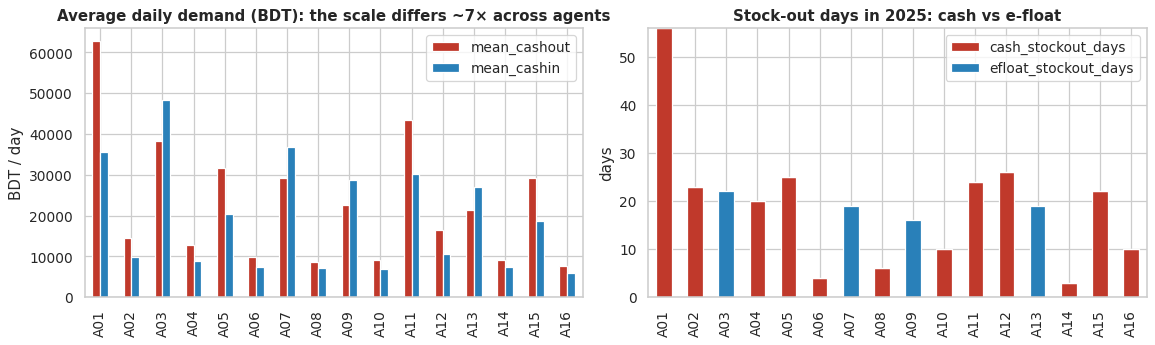

In [6]:
prof = df.groupby(["agent_id", "division", "location_type"]).agg(
    mean_cashout=("true_cashout_demand", "mean"), mean_cashin=("true_cashin_demand", "mean"),
    cash_stockout_days=("cash_stockout", "sum"), efloat_stockout_days=("efloat_stockout", "sum"),
    unserved_cashout=("unserved_cashout", "sum"), unserved_cashin=("unserved_cashin", "sum")).reset_index()
prof["net_outflow_per_day"] = prof.mean_cashout - prof.mean_cashin
display(prof.round(0).astype({c: int for c in prof.select_dtypes("number").columns}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
p = prof.set_index("agent_id")
p[["mean_cashout", "mean_cashin"]].plot.bar(ax=ax[0], color=["#c0392b", "#2980b9"])
ax[0].set_title("Average daily demand (BDT): the scale differs ~7× across agents"); ax[0].set_ylabel("BDT / day"); ax[0].set_xlabel("")
p[["cash_stockout_days", "efloat_stockout_days"]].plot.bar(stacked=True, ax=ax[1], color=["#c0392b", "#2980b9"])
ax[1].set_title("Stock-out days in 2025: cash vs e-float"); ax[1].set_ylabel("days"); ax[1].set_xlabel("")
plt.show()

**Findings.**
- Volumes span ~7× (≈৳8k to ৳55k per day). A model trained on raw taka amounts would be dominated by the biggest agents, so we will forecast **demand relative to each agent's own 28-day average** (and multiply back). This also lets the model generalize to a *new* agent.
- Two distinct risk profiles exist: **cash-out-heavy** agents (rural, garment, university, remittance-receiving) run out of **cash**, while **cash-in-heavy** urban market agents (A03, A07, A09, A13) run out of **e-float**. A system that only watched cash would be blind to a whole class of agents.

### 3.2 Weekly and monthly rhythm

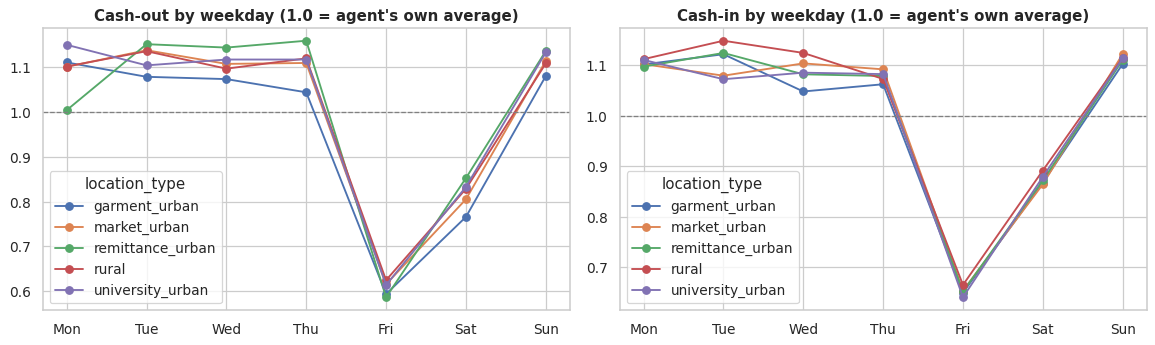

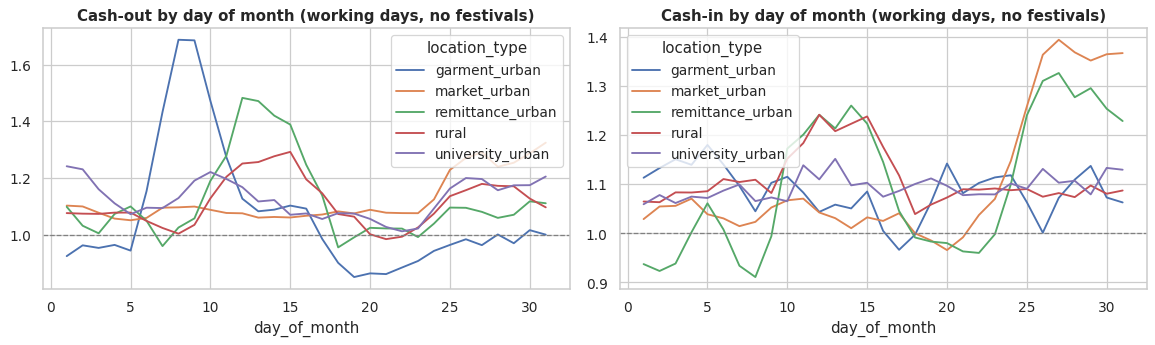

In [7]:
df["rel_co"] = df.true_cashout_demand / df.groupby("agent_id").true_cashout_demand.transform("mean")
df["rel_ci"] = df.true_cashin_demand / df.groupby("agent_id").true_cashin_demand.transform("mean")
dow = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
calm = (df.is_holiday == 0) & (df.is_eid_bonus_week == 0) & (df.is_pre_eid_fitr == 0) & (df.is_pre_eid_adha == 0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a_, col, ttl in zip(ax, ["rel_co", "rel_ci"], ["Cash-out", "Cash-in"]):
    t = df[calm].groupby(["location_type", "day_of_week"])[col].mean().unstack(0); t.index = dow
    t.plot(marker="o", ax=a_); a_.axhline(1, ls="--", c="grey", lw=1); a_.set_title(f"{ttl} by weekday (1.0 = agent's own average)")
plt.show()

m = calm & (df.is_weekend == 0)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a_, col, ttl in zip(ax, ["rel_co", "rel_ci"], ["Cash-out", "Cash-in"]):
    t = df[m].groupby(["location_type", "day_of_month"])[col].mean().unstack(0)
    t.rolling(3, center=True, min_periods=1).mean().plot(ax=a_); a_.axhline(1, ls="--", c="grey", lw=1)
    a_.set_title(f"{ttl} by day of month (working days, no festivals)")
plt.show()

**Findings.** The weekend (Friday/Saturday in Bangladesh) cuts demand sharply, and the **monthly cycle differs by agent type**: garment-area agents surge on the 7th–10th (payday), remittance and university agents have their own bumps, and urban market agents see their cash-in rise toward month-end. A single "month-end" feature would be wrong for most agents, so the model needs the *interaction* of calendar and agent type, which trees capture naturally.

### 3.3 Festivals: the strongest and most dangerous effect

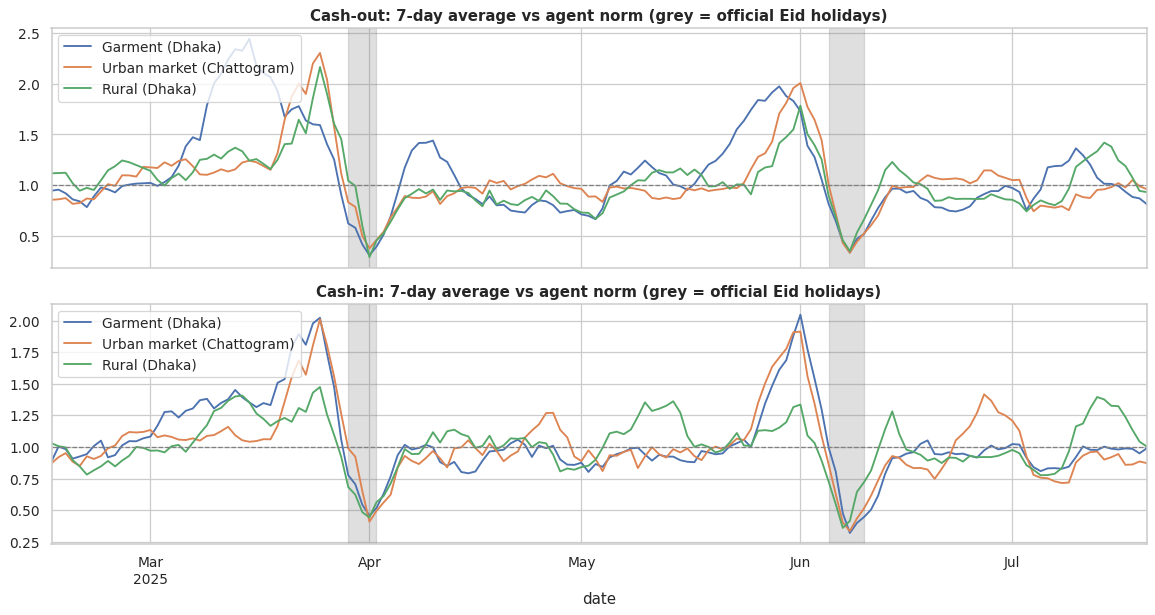

In [8]:
sel = {"A01": "Garment (Dhaka)", "A03": "Urban market (Chattogram)", "A02": "Rural (Dhaka)"}
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for a_, col, ttl in zip(ax, ["rel_co", "rel_ci"], ["Cash-out", "Cash-in"]):
    for aid, nm in sel.items():
        s = df[df.agent_id == aid].set_index("date")[col].rolling(7, center=True, min_periods=3).mean()
        s.loc["2025-02-15":"2025-07-20"].plot(ax=a_, label=nm)
    for a0, a1_ in [("2025-03-29", "2025-04-02"), ("2025-06-05", "2025-06-10")]:
        a_.axvspan(pd.Timestamp(a0), pd.Timestamp(a1_), color="grey", alpha=0.25)
    a_.axhline(1, ls="--", c="grey", lw=1); a_.set_title(f"{ttl}: 7-day average vs agent norm (grey = official Eid holidays)"); a_.legend(loc="upper left")
plt.show()

**Findings.** Demand does not simply "rise at Eid": it **builds for two to three weeks** (garment bonus week, then the pre-Eid shopping window), **collapses during the holiday**, and rebounds afterwards. The shape differs by agent type (garment cash-out surges hardest; urban cash-in jumps as people send money home). This is why the calendar needs several distinct festival features (`is_eid_bonus_week`, `is_pre_eid_*`, `is_eid_day`, `days_to_nearest_eid`) rather than one "Eid" flag.

### 3.4 Censoring: what the data hides when an agent runs out

Cash stock-out agent-days : 229 (3.9%); on those days the agent served only 70% of true cash-out demand
E-float stock-out agent-days: 76 (1.3%)
Across ALL days, observed cash-out understates true demand by only 1.89%


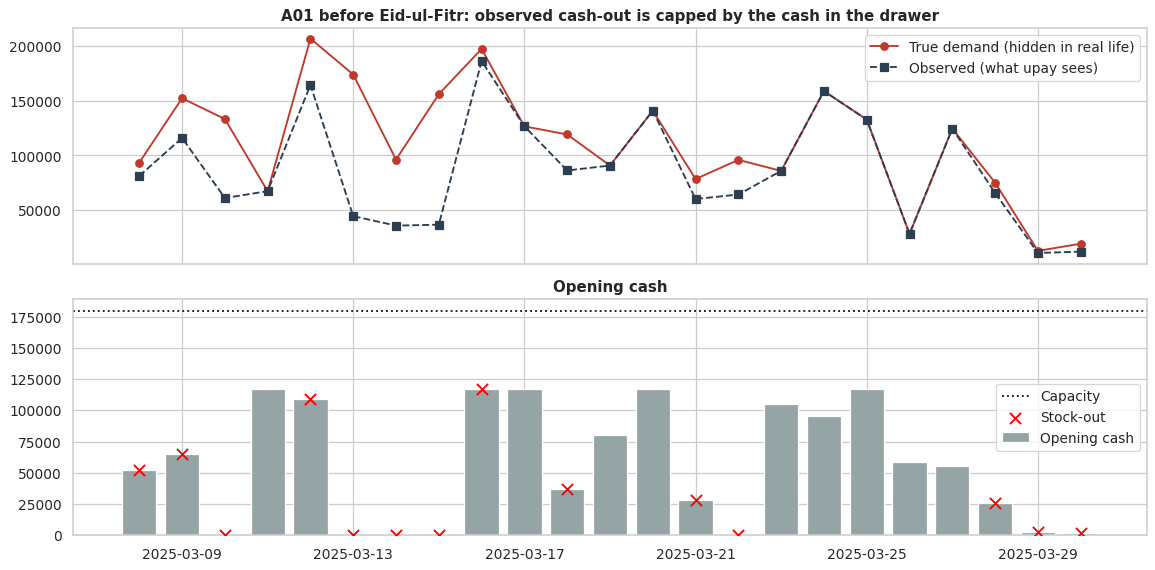

In [9]:
so = df[df.cash_stockout == 1]
print(f"Cash stock-out agent-days : {len(so)} ({len(so)/len(df):.1%}); on those days the agent served only "
      f"{so.observed_cashout.sum()/so.true_cashout_demand.sum():.0%} of true cash-out demand")
print(f"E-float stock-out agent-days: {int(df.efloat_stockout.sum())} ({df.efloat_stockout.mean():.1%})")
print(f"Across ALL days, observed cash-out understates true demand by only {1-df.observed_cashout.sum()/df.true_cashout_demand.sum():.2%}")

a = df[(df.agent_id == "A01") & df.date.between("2025-03-08", "2025-03-30")]
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax[0].plot(a.date, a.true_cashout_demand, "o-", c="#c0392b", label="True demand (hidden in real life)")
ax[0].plot(a.date, a.observed_cashout, "s--", c="#2c3e50", label="Observed (what upay sees)")
ax[0].set_title("A01 before Eid-ul-Fitr: observed cash-out is capped by the cash in the drawer"); ax[0].legend()
ax[1].bar(a.date, a.opening_cash, color="#95a5a6", label="Opening cash")
ax[1].axhline(a.agent_capacity_cash.iloc[0], c="k", ls=":", label="Capacity")
ax[1].scatter(a.date[a.cash_stockout == 1], a.opening_cash[a.cash_stockout == 1], c="red", marker="x", s=80, label="Stock-out", zorder=5)
ax[1].set_title("Opening cash"); ax[1].legend(); plt.show()

**Findings.** Stock-outs are rare overall, so the censoring bias on the whole dataset is small, **but it is concentrated exactly when it matters**: on stock-out days the observed number is a floor, not the demand. We therefore (a) train on *observed* data, because that is all a real system would have, and (b) in section 7.1 measure how much that hurts, and fix it.

### 3.5 When do stock-outs actually happen?

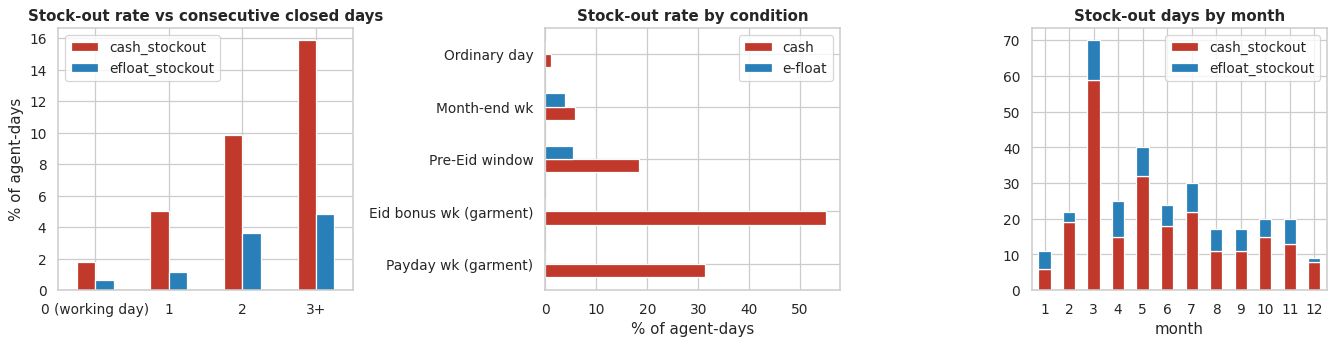

,cash stock-out %,e-float stock-out %
Payday wk (garment),31.20,0.00
Eid bonus wk (garment),55.00,0.00
Pre-Eid window,18.30,5.40
Month-end wk,5.90,3.90
Ordinary day,1.20,0.20


In [10]:
# consecutive non-working days ending today (0 on a working day): a top-up cannot arrive while this is >0
def run_nonworking(w):
    out, r = [], 0
    for x in w: r = 0 if x == 1 else r + 1; out.append(r)
    return out
df["nonworking_run"] = np.concatenate([run_nonworking(g.is_working_day.values) for _, g in df.groupby("agent_id", sort=False)])
df["nw_bucket"] = df.nonworking_run.clip(upper=3).map({0: "0 (working day)", 1: "1", 2: "2", 3: "3+"})
df["pre_eid_any"] = ((df.is_pre_eid_fitr + df.is_pre_eid_adha) > 0).astype(int)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
t = df.groupby("nw_bucket")[["cash_stockout", "efloat_stockout"]].mean() * 100
t.plot.bar(ax=ax[0], color=["#c0392b", "#2980b9"], rot=0); ax[0].set_title("Stock-out rate vs consecutive closed days"); ax[0].set_ylabel("% of agent-days"); ax[0].set_xlabel("")
flags = {"Payday wk (garment)": (df.is_salary_week == 1) & (df.garment == 1), "Eid bonus wk (garment)": (df.is_eid_bonus_week == 1) & (df.garment == 1),
         "Pre-Eid window": df.pre_eid_any == 1, "Month-end wk": df.is_month_end_week == 1, "Ordinary day": calm & (df.is_weekend == 0) & (df.is_month_end_week == 0) & (df.is_salary_week == 0)}
fl = pd.DataFrame({k: [df.loc[v, "cash_stockout"].mean() * 100, df.loc[v, "efloat_stockout"].mean() * 100] for k, v in flags.items()}, index=["cash", "e-float"]).T
fl.plot.barh(ax=ax[1], color=["#c0392b", "#2980b9"]); ax[1].set_title("Stock-out rate by condition"); ax[1].set_xlabel("% of agent-days")
mm = df.groupby("month")[["cash_stockout", "efloat_stockout"]].sum()
mm.plot.bar(ax=ax[2], stacked=True, color=["#c0392b", "#2980b9"], rot=0); ax[2].set_title("Stock-out days by month")
plt.show()
display(fl.round(1).rename(columns=lambda c: f"{c} stock-out %"))

**Findings.** Stock-outs are **not random**: they cluster in the pre-Eid / bonus-week windows, on payday weeks for garment agents, and when top-ups are blocked by consecutive closed days. That is precisely the structure a calendar-aware forecast can exploit and a static "alert below 30%" rule cannot see coming.

### 3.6 Balance trajectories

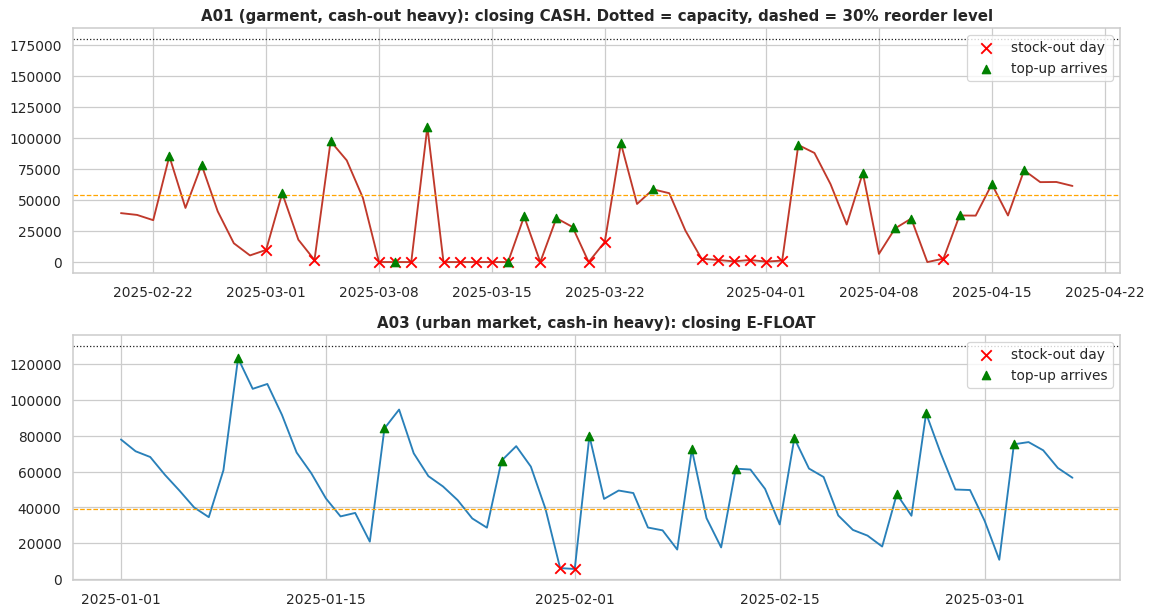

In [11]:
def traj(aid, col, cap_col, start, end, ax, title, color):
    g = df[(df.agent_id == aid) & df.date.between(start, end)]
    cap = g[cap_col].iloc[0]
    ax.plot(g.date, g[col], c=color, lw=1.5); ax.axhline(cap, c="k", ls=":", lw=1); ax.axhline(0.30 * cap, c="orange", ls="--", lw=1)
    so_col = "cash_stockout" if col == "closing_cash" else "efloat_stockout"
    ax.scatter(g.date[g[so_col] == 1], g[col][g[so_col] == 1], c="red", marker="x", s=70, zorder=5, label="stock-out day")
    tu_col = "cash_topup" if col == "closing_cash" else "efloat_topup"
    ax.scatter(g.date[g[tu_col] > 0], g[col][g[tu_col] > 0], c="green", marker="^", s=45, zorder=5, label="top-up arrives")
    ax.set_title(title); ax.legend(loc="upper right")
first_ef = df[(df.agent_id == "A03") & (df.efloat_stockout == 1)].date.min()
fig, ax = plt.subplots(2, 1, figsize=(13, 7))
traj("A01", "closing_cash", "agent_capacity_cash", "2025-02-20", "2025-04-20", ax[0], "A01 (garment, cash-out heavy): closing CASH. Dotted = capacity, dashed = 30% reorder level", "#c0392b")
traj("A03", "closing_efloat", "agent_capacity_efloat", first_ef - pd.Timedelta(days=35), first_ef + pd.Timedelta(days=35), ax[1], "A03 (urban market, cash-in heavy): closing E-FLOAT", "#2980b9")
plt.show()

**Findings.** The sawtooth is the real operational loop: balances drain, the agent notices at ~30%, a top-up lands a working day or two later. Stock-outs happen when a surge or a closure outruns that loop. The two panels show the two mirror-image failure modes.

### 3.7 What drives demand? (correlation with calendar flags)

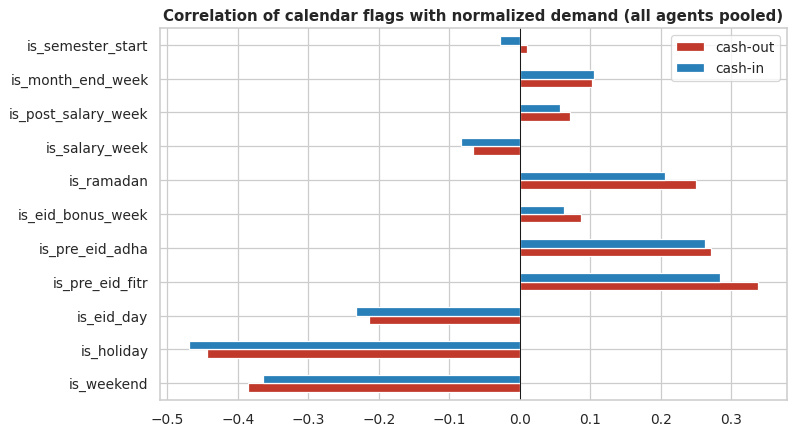

In [12]:
drivers = ["is_weekend", "is_holiday", "is_eid_day", "is_pre_eid_fitr", "is_pre_eid_adha", "is_eid_bonus_week", "is_ramadan",
           "is_salary_week", "is_post_salary_week", "is_month_end_week", "is_semester_start"]
cor = pd.DataFrame({"cash-out": [df[c].corr(df.rel_co) for c in drivers], "cash-in": [df[c].corr(df.rel_ci) for c in drivers]}, index=drivers)
cor.plot.barh(figsize=(9, 5), color=["#c0392b", "#2980b9"]); plt.axvline(0, c="k", lw=0.8)
plt.title("Correlation of calendar flags with normalized demand (all agents pooled)"); plt.show()

**Note.** Pooled correlations understate effects that apply to *one agent type only* (e.g. the garment payday surge is diluted across 16 agents). They are a sanity check, not the model.

### 3.8 Reporting quality (the daily cash self-report)

Reports missing: 4.1% | |gap| > 10% of cash: 0.41% | |gap| > 5%: 9.89%


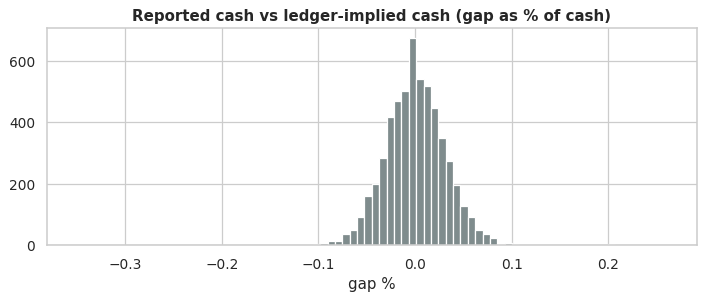

In [13]:
gap_pct = (df.reconciliation_gap / df.closing_cash.clip(lower=1)).dropna()
print(f"Reports missing: {df.report_missing.mean():.1%} | |gap| > 10% of cash: {(gap_pct.abs() > 0.10).mean():.2%} | |gap| > 5%: {(gap_pct.abs() > 0.05).mean():.2%}")
plt.figure(figsize=(8, 3.5)); gap_pct.clip(-0.4, 0.4).hist(bins=80, color="#7f8c8d"); plt.title("Reported cash vs ledger-implied cash (gap as % of cash)")
plt.xlabel("gap %"); plt.show()

**Why this matters for the app:** e-float is known automatically from the ledger, but **physical cash is self-reported**. A tight cluster around zero with a thin tail of large gaps is what the reconciliation flag in the app should catch: large gaps are flagged for admin review instead of silently poisoning the forecast's starting balance. (In this notebook the forecasting models use ledger-consistent balances; the reconciliation layer is an app-level rule.)

## 4. Problem framing: the decisions that matter more than the algorithm

**4.1 Forecast *demand*, not balances.** An agent's balance depends on their own refill habits; demand does not. So the ML model predicts daily **cash-out** and **cash-in volumes**, and balances are rolled forward *afterwards* (section 10). This also keeps business logic (buffers, safety levels) out of the model, as the rulebook asks.

**4.2 Direct multi-horizon.** One row = (agent, forecast origin *t*, horizon *h*) predicting day *t+h*, for *h* = 1…7, with *h* as a feature. The alternative (forecast day 1, feed it back in to forecast day 2, …) accumulates error and makes uncertainty hard to reason about.

**4.3 Predict a *distribution*, not a number.** "Tomorrow's cash-out will be ৳12,000" is false precision. We train quantile models (P10, P25, P50, P75, P90). Risk depends on the *upper tail* of cash-out, which a mean forecast cannot give.

**4.4 Relative target.** Target = demand ÷ the agent's 28-day average at the origin. Quantiles are scale-equivariant, so multiplying back gives valid taka quantiles. This puts a ৳8k agent and a ৳55k agent on the same footing.

**4.5 Leakage rules.** At the end of day *t* we may use history up to and including *t*, plus the *calendar* of future days (holidays and paydays are known in advance). We may **not** use anything about days after *t*, and we do not feed the agent's current balances into the demand model.

## 5. Features

In [14]:
t0 = time.time()
F = lf.make_features(df)
# stock-out flag of the TARGET day: a real system can derive this from declined / "insufficient balance" events. Used only to handle censoring (7.1).
stock = df[["agent_id", "date", "cash_stockout", "efloat_stockout"]].rename(columns={"date": "target_date", "cash_stockout": "so_c", "efloat_stockout": "so_e"})
F = F.merge(stock, on=["agent_id", "target_date"], how="left")
print(f"{F.shape[0]:,} rows (agent × origin × horizon) in {time.time()-t0:.2f}s | {len(lf.FEATURE_COLS)} model features")
groups = {"horizon": ["h"], "calendar (known in advance)": lf.CAL_COLS, "agent traits / size": lf.TRAIT_COLS + ["logcap_cash", "logcap_ef", "log_co_ci_scale"],
          "recent history (≤ origin)": [c for c in lf.FEATURE_COLS if c.startswith(("co_", "ci_"))],
          "agent-type × event crosses": lf.CROSS_COLS}
for k, v in groups.items(): print(f"  {k:30s} {len(v):2d}  e.g. {', '.join(v[:5])}")
display(F[["agent_id", "origin_date", "target_date", "h", "co_scale", "co_lag7_r", "co_roll7_r", "is_salary_week", "x_garment_is_salary_week", "y_co", "yt_co"]].head(4))

37,072 rows (agent × origin × horizon) in 0.24s | 77 model features
  horizon                         1  e.g. h
  calendar (known in advance)    19  e.g. day_of_week, day_of_month, month, days_to_month_end, is_weekend
  agent traits / size             8  e.g. urban, garment, remittance, agri, university
  recent history (≤ origin)      14  e.g. co_logscale, co_last_r, co_roll7_r, co_lag7_r, co_lag14_r
  agent-type × event crosses     35  e.g. x_urban_is_salary_week, x_garment_is_salary_week, x_remittance_is_salary_week, x_agri_is_salary_week, x_university_is_salary_week


,agent_id,origin_date,target_date,h,co_scale,co_lag7_r,co_roll7_r,is_salary_week,x_garment_is_salary_week,y_co,yt_co
0,A01,2025-01-28,2025-01-29,1,"56,366.07",0.92,0.94,0,0.00,"43,092.00","43,092.00"
1,A01,2025-01-29,2025-01-30,1,"55,830.04",0.89,0.92,0,0.00,"61,667.00","61,667.00"
2,A01,2025-01-30,2025-01-31,1,"56,478.57",0.54,0.94,0,0.00,"25,734.00","25,734.00"
3,A01,2025-01-31,2025-02-01,1,"56,132.00",0.76,0.94,0,0.00,"42,229.00","42,229.00"


**Leakage unit test.** Never trust a feature builder by reading it: recompute one row by hand with plain pandas and check that every history value used is dated on or before the origin.

In [15]:
row = F.sample(1, random_state=3).iloc[0]
g = df[df.agent_id == row.agent_id].set_index("date")
assert abs(g.loc[:row.origin_date, "observed_cashout"].tail(28).mean() - row.co_scale) < 1e-6          # 28-day scale uses only ≤ origin
d7 = row.target_date - pd.Timedelta(days=7)
assert d7 <= row.origin_date                                                                         # lag-7 value is already known at the origin
assert abs(g.loc[d7, "observed_cashout"] / row.co_scale - row.co_lag7_r) < 1e-9
assert not any(c in lf.FEATURE_COLS for c in ["cash0", "ef0", "y_co", "y_ci", "yt_co", "yt_ci", "closing_cash", "opening_cash"])
# every origin must have a full 7-day horizon of future targets, and the max lag used is 21 days
assert (F.target_date - F.origin_date).dt.days.eq(F.h).all()
print(f"Leakage checks passed (row: {row.agent_id}, origin {row.origin_date.date()}, h={row.h}, target {row.target_date.date()}).")

Leakage checks passed (row: A14, origin 2025-04-02, h=4, target 2025-04-06).


## 6. Chronological split

Random splits leak the future into training (Tuesday's neighbour is in the train set). We split by **target date**:

| Set | Target dates | Role |
|---|---|---|
| Train | Jan → 31 Jul | fit the models (contains **both** Eids) |
| Validation | August | early stopping only |
| Test | Sep → Dec | final, untouched evaluation (Durga Puja, Victory Day, Christmas; no Eid) |

Features for a test row only use history up to its origin, so nothing from the test period reaches training.

In [16]:
TR = F.target_date <= "2025-07-31"
VA = F.target_date.between("2025-08-01", "2025-08-31")
TE = F.target_date >= "2025-09-01"
print(f"train {TR.sum():,} | validation {VA.sum():,} | test {TE.sum():,} rows")
print("Test-period holidays:", sorted(df[(df.date >= "2025-09-01") & (df.is_holiday == 1)].date.dt.strftime("%b %d").unique()))
cols = lf.FEATURE_COLS

train 20,272 | validation 3,472 | test 13,328 rows
Test-period holidays: ['Dec 16', 'Dec 25', 'Oct 01', 'Oct 02']


> **Honest limitation:** with one year of data the chronological test period contains **no Eid**. To test festival behaviour we add a dedicated hold-out in section 9.

## 7. Baselines, a first model, and why one accuracy number is not enough

A model only earns its place by beating something simple. Two baselines: **same weekday last week** (seasonal naive) and the **agent's 28-day average**. Metric: **WAPE** = Σ|error| / Σ|actual| (an honest "percent error" that does not explode on small values).

In [17]:
def wape(p, t): p, t = np.asarray(p, float), np.asarray(t, float); return np.abs(p - t).sum() / np.abs(t).sum()
PARAMS = dict(objective="quantile", learning_rate=0.03, num_leaves=15, min_data_in_leaf=40, bagging_fraction=0.8, bagging_freq=1,
              feature_fraction=0.8, lambda_l2=1.0, verbose=-1, seed=SEED)

def fit_one(X, y, tr, va, tau, rounds=None):
    p = {**PARAMS, "alpha": tau}
    if rounds is None:      # early stopping on the validation month
        return lgb.train(p, lgb.Dataset(X.loc[tr], y[tr]), 2000, valid_sets=[lgb.Dataset(X.loc[va], y[va])], callbacks=[lgb.early_stopping(60, verbose=False)])
    return lgb.train(p, lgb.Dataset(X.loc[tr], y[tr]), rounds)

def fit_models(F, tr, va=None, cols=lf.FEATURE_COLS, taus=lf.QUANTILES, censoring_aware=True, label="obs", rounds=None, p1_rounds=None):
    # Quantile models for cash-out and cash-in on the RELATIVE target (demand / the agent's 28-day mean).
    # censoring_aware: on days the agent ran out, the observed value is only a FLOOR on demand. We replace it by
    #     max(observed, pass-1 P75 forecast) and refit. Uses only what a real system has (stock-out flag + a first-pass model).
    # label="true": oracle trained on true demand, a diagnostic upper bound that real data can never give.
    models, info = {"co": {}, "ci": {}}, {}
    for flow, so in (("co", "so_c"), ("ci", "so_e")):
        sc = F[f"{flow}_scale"]
        y = (F[f"yt_{flow}"] if label == "true" else F[f"y_{flow}"]) / sc
        if censoring_aware and label == "obs":
            c = F[so] == 1
            p1 = fit_one(F[cols], y, tr, va, 0.75, None if p1_rounds is None else p1_rounds[flow])
            info[(flow, "p1")] = p1.best_iteration if p1_rounds is None else p1_rounds[flow]
            y = y.copy(); y[c] = np.maximum(y[c], p1.predict(F.loc[c, cols]))
        for tau in taus:
            m = fit_one(F[cols], y, tr, va, tau, None if rounds is None else rounds[(flow, tau)])
            models[flow][tau], info[(flow, tau)] = m, (m.best_iteration if rounds is None else rounds[(flow, tau)])
    return models, info

loc_type, division = loc_of.location_type, loc_of.division
Te = F[TE].reset_index(drop=True)
Te["location_type"], Te["division"] = Te.agent_id.map(loc_type), Te.agent_id.map(division)
base_rows = []
for flow, nm in (("co", "Cash-out"), ("ci", "Cash-in")):
    obs = Te[f"y_{flow}"]
    base_rows.append({"target": nm, "same weekday last week": wape(Te[f"{flow}_lag7_r"] * Te[f"{flow}_scale"], obs), "agent's 28-day mean": wape(Te[f"{flow}_scale"], obs)})
display(pd.DataFrame(base_rows).set_index("target").style.format("{:.3f}").set_caption("Baselines: WAPE on the test period (vs observed demand)"))

,same weekday last week,agent's 28-day mean
target,,
Cash-out,0.315,0.272
Cash-in,0.303,0.252


### 7.1 A first model: it looks great, and it hides a serious flaw

We start with the obvious approach (calendar + history features, trained on observed demand) and look at it two ways: the **single headline number**, and **slices defined by calendar events known in advance** (payday, post-payday, ordinary days). Slicing by *outcome* ("days where demand turned out high") would be misleading, because it selects days where random noise happened to be high. Slicing by *calendar* does not.

We then try two fixes and compare. "Bias" below is `Σ predicted / Σ true demand − 1` on that slice, so **0% is perfect and −38% means the model predicted 38% too little**.

In [18]:
def slice_masks(T):
    ordinary = (T.is_working_day == 1) & (T.is_salary_week == 0) & (T.is_post_salary_week == 0) & (T.is_month_end_week == 0)
    return {"garment payday week": (T.garment == 1) & (T.is_salary_week == 1) & (T.is_working_day == 1),
            "remittance post-payday": (T.remittance == 1) & (T.is_post_salary_week == 1) & (T.is_working_day == 1),
            "ordinary working day": ordinary}
VARIANTS = {
    "A. first model (base features, observed labels)":            dict(cols=lf.BASE_FEATURE_COLS, censoring_aware=False, label="obs"),
    "B. + agent-type × event interaction features":               dict(cols=lf.FEATURE_COLS,      censoring_aware=False, label="obs"),
    "C. + censoring-aware labels  (= FINAL approach)":            dict(cols=lf.FEATURE_COLS,      censoring_aware=True,  label="obs"),
    "Oracle: trained on TRUE demand (impossible in practice)":    dict(cols=lf.FEATURE_COLS,      censoring_aware=False, label="true")}
rows = []
for name, kw in VARIANTS.items():
    m, _ = fit_models(F, TR, VA, taus=[0.5], **kw)
    for flow, nm, so in (("co", "Cash-out", "so_c"), ("ci", "Cash-in", "so_e")):
        p = pd.Series(m[flow][0.5].predict(Te[kw["cols"]]) * Te[f"{flow}_scale"].values, index=Te.index); t = Te[f"yt_{flow}"]; s_ = Te[so] == 1
        r = {"model": name, "target": nm, "WAPE (all days)": wape(p, Te[f"y_{flow}"]), "bias: stock-out days": p[s_].sum() / t[s_].sum() - 1}
        r.update({f"bias: {k}": p[mk].sum() / t[mk].sum() - 1 for k, mk in slice_masks(Te).items()}); rows.append(r)
V = pd.DataFrame(rows); SUMMARY["variants"] = V.to_dict("records")
fmt = {c: "{:+.1%}" for c in V.columns if c.startswith("bias")}; fmt["WAPE (all days)"] = "{:.3f}"
display(V[V.target == "Cash-out"].set_index("model").drop(columns="target").style.format(fmt).set_caption("CASH-OUT, test period Sep–Dec"))
display(V[V.target == "Cash-in"].set_index("model").drop(columns="target").style.format(fmt).set_caption("CASH-IN, test period Sep–Dec"))

,WAPE (all days),bias: stock-out days,bias: garment payday week,bias: remittance post-payday,bias: ordinary working day
model,,,,,
"A. first model (base features, observed labels)",0.179,-27.0%,-37.7%,-13.0%,+0.7%
B. + agent-type × event interaction features,0.172,-21.5%,-21.3%,-11.0%,-1.3%
C. + censoring-aware labels (= FINAL approach),0.171,-11.4%,-0.3%,-5.9%,-1.7%
Oracle: trained on TRUE demand (impossible in practice),0.171,-11.4%,-0.5%,-7.3%,-1.9%


,WAPE (all days),bias: stock-out days,bias: garment payday week,bias: remittance post-payday,bias: ordinary working day
model,,,,,
"A. first model (base features, observed labels)",0.177,-20.5%,-2.6%,-14.3%,+1.0%
B. + agent-type × event interaction features,0.175,-20.7%,-3.8%,-6.8%,+0.3%
C. + censoring-aware labels (= FINAL approach),0.175,-17.6%,-3.9%,-6.0%,+0.4%
Oracle: trained on TRUE demand (impossible in practice),0.175,-17.1%,-4.0%,-5.7%,+0.4%


**What the tables show (cash-out, test period):**

- The headline barely moves across the variants (WAPE 0.179 → 0.171), yet the **first model under-predicts garment payday demand by 38%** while being almost exactly right on ordinary days (+0.7%). The average was dominated by ordinary days and hid the days that cause stock-outs.
- **Two separate causes, two fixes.**
  1. *A rare, type-specific effect.* The payday surge hits one agent type for about 4 days a month; a tree has too few examples to discover it unaided. Giving it the interaction explicitly (agent type × event) halves the bias (B: −21%).
  2. *Censoring.* Garment agents run out of cash in roughly a quarter to a third of payday-week days, so the observed demand on those days is **capped by the cash in the drawer**, and a model trained on it learns the capped number. Variant C treats a stock-out day's label as a *lower bound* and replaces it with max(observed, first-pass P75 forecast). The bias drops to **−0.3%, indistinguishable from the oracle trained on true demand (−0.5%)**, using only information a real system has (a stock-out flag and a first-pass model).
- **The −11% that remains on stock-out days is not a flaw to fix**: even the oracle has it. Days are *classified* as stock-outs because demand came in unusually high, so no forecast of the *expected* demand can anticipate those random spikes (selection effect).
- Remittance post-payday improves from −13% to −6% (oracle −7%): the remaining gap there is a modelling limit, not censoring.
- Cash-in barely changes, as expected: the garment-payday slice does not apply to it, and its −17% on stock-out days is the same selection effect (oracle −17%).

**Lesson.** Evaluate on slices that match the decision the model feeds. One average accuracy number can hide a model that is nearly blind exactly when it matters.

### 7.2 Final models: all five quantiles with the censoring-aware approach

Same recipe as variant C, now for all five quantiles (P10…P90) of both flows.

In [19]:
t0 = time.time()
models, info = fit_models(F, TR, VA)                                  # censoring-aware, interaction features, early-stopped on August
best_iter = {k: v for k, v in info.items() if k[1] != "p1"}; p1_best = {f: info[(f, "p1")] for f in ("co", "ci")}
print(f"Trained {len(best_iter)} quantile models (+2 pass-1 imputation models) in {time.time()-t0:.1f}s")
display(pd.Series(best_iter).unstack().rename(index={"co": "cash-out", "ci": "cash-in"}).rename_axis("trees at quantile →"))
eval_bundle = dict(models=models, feature_cols=cols, quantiles=lf.QUANTILES)
Q = lf.predict_quantiles(eval_bundle, Te)

rows = []
for flow, nm in (("co", "Cash-out"), ("ci", "Cash-in")):
    obs, tru, p50 = Te[f"y_{flow}"], Te[f"yt_{flow}"], Q[flow][:, 2]
    naive = Te[f"{flow}_lag7_r"] * Te[f"{flow}_scale"]
    rows.append({"target": nm, "WAPE model": wape(p50, obs), "WAPE same-weekday-last-week": wape(naive, obs), "WAPE 28-day mean": wape(Te[f"{flow}_scale"], obs),
                 "WAPE model vs TRUE demand": wape(p50, tru), "improvement vs naive": 1 - wape(p50, obs) / wape(naive, obs)})
res = pd.DataFrame(rows).set_index("target"); display(res.style.format("{:.3f}"))
SUMMARY["wape_test"] = res.to_dict("index")

# What is the best any forecaster could do? The generator adds lognormal noise; even a perfect model of the calendar cannot predict it.
sig = agents.set_index("agent_id").noise_std; w = agents.set_index("agent_id").base_cashout
x = np.random.default_rng(0).lognormal(0, 1, 400_000)
floor = {a: np.abs(np.exp(s * np.log(x)) - 1).mean() / np.exp(s ** 2 / 2) for a, s in sig.items()}      # E|X-median| / E[X] for lognormal(0, s)
floor_w = sum(floor[a] * w[a] for a in sig.index) / w.sum()
print(f"Irreducible noise floor (volume-weighted, from the generator's noise): WAPE ≈ {floor_w:.3f}")
SUMMARY["noise_floor_wape"] = float(floor_w)

Trained 10 quantile models (+2 pass-1 imputation models) in 12.0s


,0.10,0.25,0.50,0.75,0.90
trees at quantile →,,,,,
cash-in,140,110,125,752,707
cash-out,186,158,171,263,248


,WAPE model,WAPE same-weekday-last-week,WAPE 28-day mean,WAPE model vs TRUE demand,improvement vs naive
target,,,,,
Cash-out,0.171,0.315,0.272,0.168,0.459
Cash-in,0.175,0.303,0.252,0.174,0.422


Irreducible noise floor (volume-weighted, from the generator's noise): WAPE ≈ 0.161


**Reading this.** The final model's error is **0.171 (cash-out) and 0.175 (cash-in)**, against 0.315 and 0.303 for "same weekday last week", i.e. about **46% and 42% lower**, and within roughly 0.01–0.015 of the irreducible noise floor (0.161). Against *true* demand, which no real system can see, the error is 0.168 / 0.174.

Two caveats. The floor exists only because **we** injected the noise; on real data the achievable error is unknown, so this shows the *pipeline* works, not that real data would reach these numbers. And the upper-quantile cash-in models (P75, P90) need 700+ trees versus roughly 110–260 for the rest: the tails are the hard part to learn.

## 8. Evaluation deep-dive: horizon, calibration, fairness, explanation

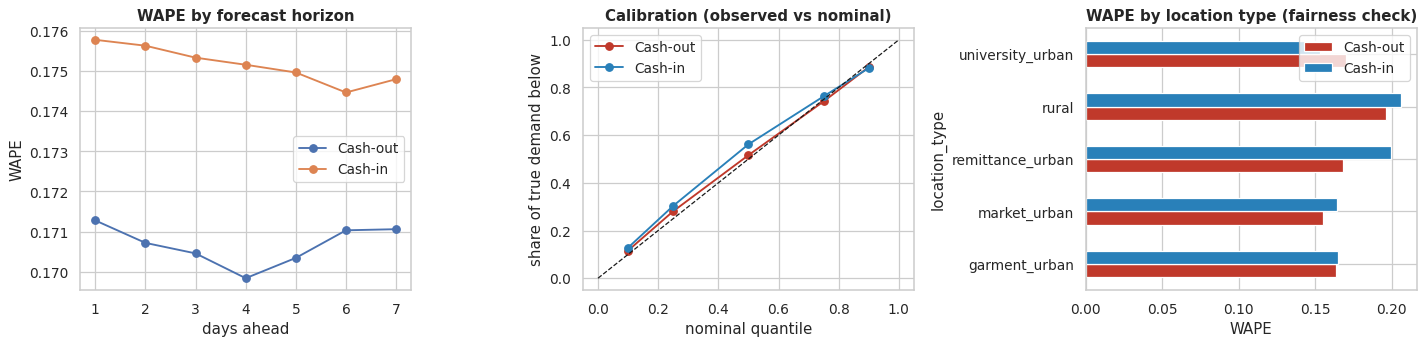

80% prediction interval (P10–P90) covers true demand: cash-out 77.0%, cash-in 75.3%  (nominal 80%)


,Cash-out,Cash-in,noise floor (mean of agents)
location_type,,,
garment_urban,0.164000,0.165000,0.143000
market_urban,0.155000,0.164000,0.159000
remittance_urban,0.168000,0.199000,0.159000
rural,0.196000,0.206000,0.195000
university_urban,0.170000,0.153000,0.139000


,1,2,3,4,5,6,7
Cash-out,0.171000,0.171000,0.170000,0.170000,0.170000,0.171000,0.171000
Cash-in,0.176000,0.176000,0.175000,0.175000,0.175000,0.174000,0.175000


,0.100000,0.250000,0.500000,0.750000,0.900000
cash-out,0.116000,0.281000,0.516000,0.742000,0.886000
cash-in,0.128000,0.303000,0.562000,0.763000,0.881000


In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# (a) error by horizon
hz = pd.DataFrame({nm: [wape(Q[f][Te.h == h, 2], Te.loc[Te.h == h, f"y_{f}"]) for h in range(1, 8)] for f, nm in (("co", "Cash-out"), ("ci", "Cash-in"))}, index=range(1, 8))
hz.plot(marker="o", ax=ax[0]); ax[0].set_title("WAPE by forecast horizon"); ax[0].set_xlabel("days ahead"); ax[0].set_ylabel("WAPE")
# (b) calibration: fraction of TRUE demand below each predicted quantile (ideal = diagonal)
for f, nm, c in (("co", "Cash-out", "#c0392b"), ("ci", "Cash-in", "#2980b9")):
    ax[1].plot(lf.QUANTILES, [(Te[f"yt_{f}"] <= Q[f][:, j]).mean() for j in range(5)], "o-", c=c, label=nm)
ax[1].plot([0, 1], [0, 1], "k--", lw=1); ax[1].set_title("Calibration (observed vs nominal)"); ax[1].set_xlabel("nominal quantile"); ax[1].set_ylabel("share of true demand below"); ax[1].legend()
# (c) error by agent type
bt = pd.DataFrame({nm: Te.groupby("location_type").apply(lambda g, f=f: wape(Q[f][g.index, 2], g[f"y_{f}"])) for f, nm in (("co", "Cash-out"), ("ci", "Cash-in"))})
bt.plot.barh(ax=ax[2], color=["#c0392b", "#2980b9"]); ax[2].set_title("WAPE by location type (fairness check)"); ax[2].set_xlabel("WAPE")
plt.show()
cov = {f: ((Te[f"yt_{f}"] >= Q[f][:, 0]) & (Te[f"yt_{f}"] <= Q[f][:, 4])).mean() for f in ("co", "ci")}
print(f"80% prediction interval (P10–P90) covers true demand: cash-out {cov['co']:.1%}, cash-in {cov['ci']:.1%}  (nominal 80%)")
SUMMARY["interval_80_coverage"] = cov
bt["noise floor (mean of agents)"] = pd.Series(floor).groupby(loc_type).mean()
display(bt.round(3).style.set_caption("WAPE by location type vs the irreducible noise floor of that type"))
display(hz.T.round(3).style.set_caption("WAPE by days ahead"))
display(pd.DataFrame({nm: [(Te[f"yt_{f}"] <= Q[f][:, j]).mean() for j in range(5)] for f, nm in (("co", "cash-out"), ("ci", "cash-in"))}, index=lf.QUANTILES).T.round(3).style.set_caption("Share of TRUE demand below each predicted quantile (ideal = column header)"))

**Reading this.**
- **Horizon: flat, and that is a property of the synthetic data, not a strength of the model.** Error is 0.170–0.171 for every horizon from 1 to 7 days. The generator's daily noise is independent from one day to the next and the pattern is almost purely calendar-driven, so a week ahead is as predictable as tomorrow. Real data has persistent shocks (a rainy week, a local event), and its error would grow with horizon.
- **Calibration is close to nominal.** The share of true demand below P10 / P25 / P50 / P75 / P90 is 12% / 28% / 52% / 74% / 89% for cash-out and 13% / 30% / 56% / 76% / 88% for cash-in. The tails are slightly too tight, so the nominal 80% interval covers **77% and 75%**. The risk engine inherits this mild overconfidence.
- **Fairness.** Errors differ across agent types, but mostly **track each type's own noise level**: rural agents have the highest error (0.20–0.21) and also the highest noise floor (0.195). The one segment clearly above its floor is **remittance-urban cash-in** (0.199 vs 0.159, a single agent, A11), which is where to look first for a modelling gap.

### 8.1 Example forecast, with an explanation

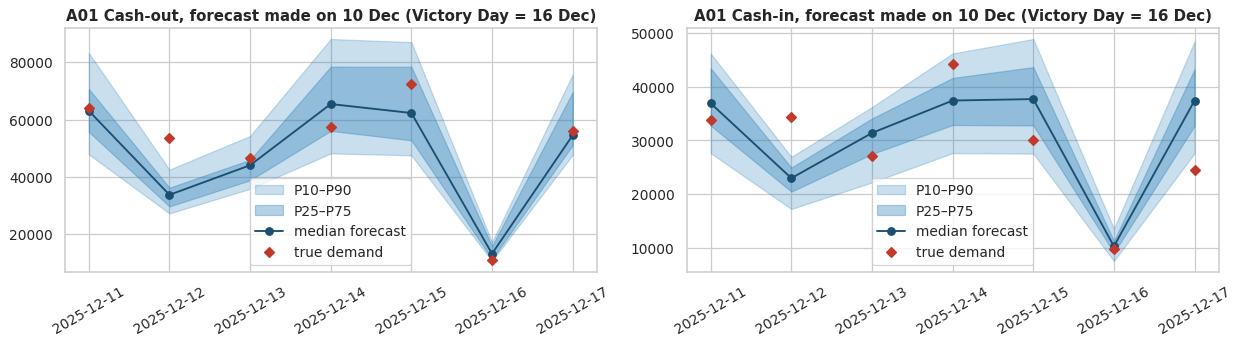

A01, cash-out forecast for Mon 8 Sep (a garment payday-week day): median ৳100,263 | true demand ৳130,552 | model's average level ৳56,069
What moved the forecast away from that average (BDT; 'feature: value'):
     +31,966  garment-area agent x salary week: yes
      +8,583  Working day: yes
      +3,184  Public holiday: no
      +1,389  Weekend (Fri/Sat): no
      +1,030  Friday: no
        -826  Distance to nearest Eid: -30
        -628  Pre-Eid-ul-Fitr shopping window: no


In [21]:
ex = Te[(Te.agent_id == "A01") & (Te.origin_date == "2025-12-10")].sort_values("h")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a_, f, nm in zip(ax, ("co", "ci"), ("Cash-out", "Cash-in")):
    ix = ex.index.values
    a_.fill_between(ex.target_date, Q[f][ix, 0], Q[f][ix, 4], alpha=0.25, color="#2980b9", label="P10–P90")
    a_.fill_between(ex.target_date, Q[f][ix, 1], Q[f][ix, 3], alpha=0.35, color="#2980b9", label="P25–P75")
    a_.plot(ex.target_date, Q[f][ix, 2], "o-", c="#1b4f72", label="median forecast")
    a_.plot(ex.target_date, ex[f"yt_{f}"], "D", c="#c0392b", label="true demand")
    a_.set_title(f"A01 {nm}, forecast made on 10 Dec (Victory Day = 16 Dec)"); a_.legend(); a_.tick_params(axis="x", rotation=30)
plt.show()

row = Te[(Te.agent_id == "A01") & (Te.target_date == "2025-09-08") & (Te.h == 1)]
pairs, base = lf.explain_prediction(eval_bundle, row, "co", top=7)
print(f"A01, cash-out forecast for Mon 8 Sep (a garment payday-week day): median ৳{Q['co'][row.index[0], 2]:,.0f} | true demand ৳{row.yt_co.iloc[0]:,.0f} | model's average level ৳{base:,.0f}")
print("What moved the forecast away from that average (BDT; 'feature: value'):")
for lab, v in pairs: print(f"  {v:+10,.0f}  {lab}")

**This is the explanation the app shows**: not "the model said so" but "payday week for a garment-area agent adds about ৳X". Each line reads *feature: its value on that day*, with the exact tree-SHAP contribution in taka (LightGBM `pred_contrib`). Read signs carefully: a line like "public holiday: no" with a positive number does not mean holidays raise demand; it means *this is not a holiday, so the forecast moves up from the all-days average* (which includes low-demand holidays).

### 8.2 What the model actually uses

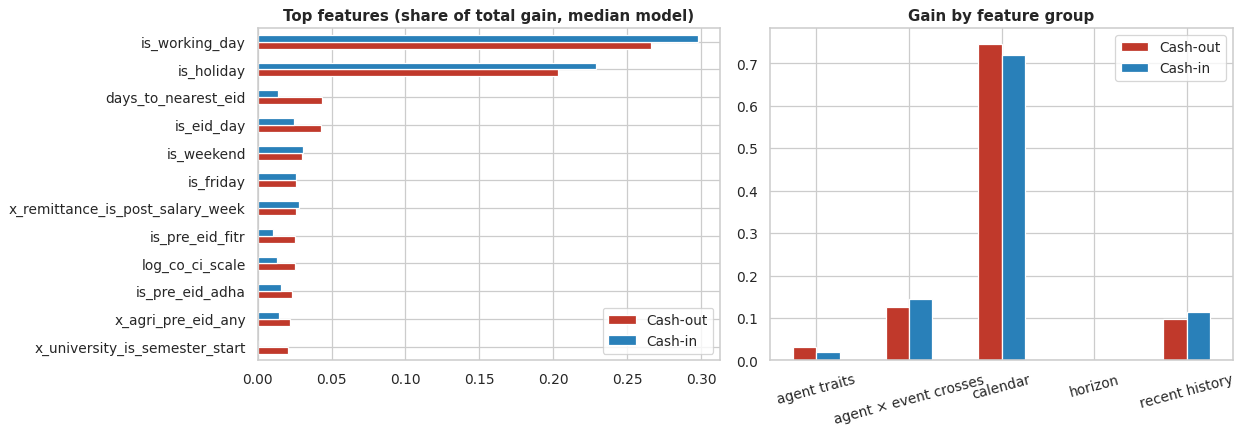

,Cash-out,Cash-in
agent traits,0.031000,0.020000
agent × event crosses,0.126000,0.145000
calendar,0.746000,0.721000
horizon,0.000000,0.000000
recent history,0.097000,0.115000


,Cash-out,Cash-in
is_working_day,0.266000,0.298000
is_holiday,0.203000,0.229000
days_to_nearest_eid,0.044000,0.014000
is_eid_day,0.043000,0.024000
is_weekend,0.030000,0.031000
is_friday,0.026000,0.026000


In [22]:
imp = {}
for flow, nm in (("co", "Cash-out"), ("ci", "Cash-in")):
    g = pd.Series(models[flow][0.5].feature_importance("gain"), index=cols); imp[nm] = g / g.sum()
imp = pd.DataFrame(imp)
grp = {c: "calendar" for c in lf.CAL_COLS}; grp.update({c: "agent traits" for c in lf.TRAIT_COLS + ["logcap_cash", "logcap_ef", "log_co_ci_scale"]})
grp.update({c: "recent history" for c in cols if c.startswith(("co_", "ci_"))}); grp.update({c: "agent × event crosses" for c in lf.CROSS_COLS}); grp["h"] = "horizon"
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
imp.sort_values("Cash-out").tail(12).plot.barh(ax=ax[0], color=["#c0392b", "#2980b9"]); ax[0].set_title("Top features (share of total gain, median model)")
imp.groupby(imp.index.map(grp)).sum().plot.bar(ax=ax[1], color=["#c0392b", "#2980b9"], rot=15); ax[1].set_title("Gain by feature group")
plt.show()
display(imp.groupby(imp.index.map(grp)).sum().round(3).style.set_caption("Share of total gain by feature group (median models)"))
display(imp.sort_values("Cash-out", ascending=False).head(6).round(3).style.set_caption("Top 6 features by gain (cash-out)"))

**Reading this.** About **three quarters of the model's gain comes from calendar features**, and `is_working_day` plus `is_holiday` alone account for roughly half: the *shape* of demand is dominated by closures and festivals. The agent-type × event crosses add another 13–15% (the payday, bonus and semester effects that apply to one kind of agent), recent history adds about 10–12% (the *level*), and static traits only 2–3%. That is the division of labour the relative target was designed to produce: shape from the calendar, level from history.

## 9. Stress tests the chronological split cannot give us

**(a) Festival hold-out.** Remove the whole Eid-ul-Adha window (19 May → 20 Jun: bonus week, pre-Eid, holidays) from training and forecast it. The model has seen Eid-ul-Fitr but never this one: can it *transfer* the festival pattern? (This is a blocked hold-out, not a time-ordered simulation: the training set includes later months.)

**(b) Cold start.** Remove two agents completely (a university agent and a rural remittance agent) and forecast them from agents of the same *type*. This is the "new agent joins upay" case.

In [23]:
def q50_models(train_mask, val_mask):
    return fit_models(F, train_mask, val_mask, taus=[0.5])[0]
def eval_q50(m, mask):
    X = F.loc[mask]; r = {}
    for flow, nm in (("co", "Cash-out"), ("ci", "Cash-in")):
        p = m[flow][0.5].predict(X[cols]) * X[f"{flow}_scale"]
        r[nm] = {"model": wape(p, X[f"y_{flow}"]), "same-weekday baseline": wape(X[f"{flow}_lag7_r"] * X[f"{flow}_scale"], X[f"y_{flow}"])}
    return pd.DataFrame(r).T

# (a) festival hold-out
adha = F.target_date.between("2025-05-19", "2025-06-20")
m_a = q50_models(~adha & ~VA, VA & ~adha)
held = eval_q50(m_a, adha)
seen = eval_q50(models, adha)   # main model HAS seen Adha in training (reference, not a fair test)
fest = pd.concat({"Adha HELD OUT of training": held[["model"]], "reference: Adha seen in training": seen[["model"]], "baseline": held[["same-weekday baseline"]].rename(columns={"same-weekday baseline": "model"})}, axis=1)
fest.columns = fest.columns.droplevel(1); print("(a) Eid-ul-Adha window (19 May – 20 Jun), WAPE vs observed demand"); display(fest.style.format("{:.3f}"))
SUMMARY["festival_holdout"] = fest.to_dict("index")

# (b) cold start
hold = ["A05", "A12"]
m_b = q50_models(TR & ~F.agent_id.isin(hold), VA & ~F.agent_id.isin(hold))
tm = TE & F.agent_id.isin(hold)
cs = pd.concat({"agent NEVER seen": eval_q50(m_b, tm)[["model"]], "agent seen in training": eval_q50(models, tm)[["model"]],
                "baseline": eval_q50(m_b, tm)[["same-weekday baseline"]].rename(columns={"same-weekday baseline": "model"})}, axis=1)
cs.columns = cs.columns.droplevel(1); print("\n(b) Cold start: held-out agents A05 (university) and A12 (rural remittance), test period, WAPE"); display(cs.style.format("{:.3f}"))
SUMMARY["cold_start"] = cs.to_dict("index")

(a) Eid-ul-Adha window (19 May – 20 Jun), WAPE vs observed demand


,Adha HELD OUT of training,reference: Adha seen in training,baseline
Cash-out,0.292,0.175,0.705
Cash-in,0.229,0.168,0.715



(b) Cold start: held-out agents A05 (university) and A12 (rural remittance), test period, WAPE


,agent NEVER seen,agent seen in training,baseline
Cash-out,0.172,0.169,0.291
Cash-in,0.174,0.169,0.290


**Reading this.**
- **(a) Festival transfer is partial.** Never having seen Eid-ul-Adha, the model scores WAPE **0.29 (cash-out) / 0.23 (cash-in)** on that window, against 0.175 / 0.168 if it *had* seen it, and 0.705 / 0.715 for the same-weekday baseline, which collapses at festivals because last week is not informative. So the model learned the festival *mechanism* well enough to cut the baseline's error by 59-68%, but one festival in training is thin evidence and a visible gap to a model that has seen it remains. A second year of data is the fix. (Ramadan overlaps the Fitr pre-festival window in training, which likely confounds the two effects.)
- **(b) Cold start works.** Agents never seen in training are forecast almost as well as seen ones (0.172 vs 0.169 cash-out, 0.174 vs 0.169 cash-in; baseline about 0.29). Because targets are relative to each agent's own level and the traits describe its type, a **new agent can be forecast from day 29 of its history without retraining**.

## 10. From demand forecast to risk: the Monte Carlo roll-forward

The quantile models say *how much will be demanded*. The agent's question is *"will I run out?"*, which depends on the **balance** too. We answer it by simulation:

1. For each of the next 7 days, sample cash-out and cash-in from the predicted distribution (a piecewise-linear curve through P10…P90, extrapolated in the tails; days and flows sampled independently, a simplification).
2. Roll the balances forward: `cash(k) = cash(0) − Σ(cash-out − cash-in)`, `e-float(k) = e-float(0) + Σ(cash-out − cash-in)`.
3. Count the share of 2,000 simulated futures where a balance falls below a **buffer** (10% of capacity, "effectively out") by day *k*.

That share **is** outputs 1 and 2. Output 5 (recommended level) is a *rule* on top: "hold enough to survive the days until a top-up can arrive, with 95% probability". The window is `closed days ahead + 2` days, so it automatically lengthens before weekends and Eid holidays. Because the rule lives in `risk_config`, the business can change the buffer or the coverage without retraining anything.

**Two risk numbers, deliberately.** "Risk within 7 days if you do nothing" is high for almost every cash-out-heavy agent, because balances always drain eventually, so it is a poor alarm. The actionable number is **risk before the next top-up can arrive** (the coverage window), so the app headlines that one and keeps the 7-day curve as context.

In [24]:
cfg = dict(lf.DEFAULT_RISK_CONFIG); COVS = (0.80, 0.90, 0.95, 0.99)
Te_r = Te[Te.origin_date <= "2025-12-24"].reset_index(drop=True)      # origins with a full 7-day future
QR = lf.predict_quantiles(eval_bundle, Te_r)
rng = np.random.default_rng(SEED); recs = []; t0 = time.time()
for (aid, od), g in Te_r.groupby(["agent_id", "origin_date"], sort=True):
    g = g.sort_values("h"); ix = g.index.values; r0 = g.iloc[0]
    out = lf.risk_summary(QR["co"][ix], QR["ci"][ix], lf.QUANTILES, r0.cash0, r0.ef0, r0.cap_cash, r0.cap_ef, int(r0.closed_ahead_origin),
                          r0.co_scale, r0.ci_scale, cfg, rng, extra_coverage=COVS)
    net_true = np.cumsum(g.yt_co.values - g.yt_ci.values)                    # COUNTERFACTUAL truth: what would happen with no top-up
    br_c = np.maximum.accumulate((r0.cash0 - net_true) < cfg["buffer_frac"] * r0.cap_cash)
    br_e = np.maximum.accumulate((r0.ef0 + net_true) < cfg["buffer_frac"] * r0.cap_ef)
    W = out["coverage_window_days"]
    recs.append(dict(agent_id=aid, origin_date=od, W=W, closed=int(r0.closed_ahead_origin), cash0=r0.cash0, ef0=r0.ef0, cap_cash=r0.cap_cash, cap_ef=r0.cap_ef,
                     co_scale=r0.co_scale, ci_scale=r0.ci_scale,
                     risk_c_w=out["cash_risk_pct_by_day"][W - 1] / 100, risk_c_7=out["cash_risk_pct_7d"] / 100,
                     risk_e_w=out["efloat_risk_pct_by_day"][W - 1] / 100, risk_e_7=out["efloat_risk_pct_7d"] / 100,
                     lab_c_w=int(br_c[W - 1]), lab_c_7=int(br_c[-1]), lab_e_w=int(br_e[W - 1]), lab_e_7=int(br_e[-1]), req_by_cov=out["req_by_coverage"],
                     float_gap=max(0.0, sum(out["req_by_coverage"][0.95]) - (r0.cash0 + r0.ef0))))
R = pd.DataFrame(recs)
print(f"Risk engine ran for {len(R):,} agent-days in {time.time()-t0:.1f}s | window length W: {R.W.value_counts().sort_index().to_dict()}")
print(f"Counterfactual breach rates (no top-up): cash within W days {R.lab_c_w.mean():.1%}, within 7 days {R.lab_c_7.mean():.1%} | "
      f"e-float within W {R.lab_e_w.mean():.1%}, within 7 days {R.lab_e_7.mean():.1%}")

Risk engine ran for 1,952 agent-days in 5.2s | window length W: {1: 16, 2: 1328, 3: 288, 4: 272, 5: 32, 6: 16}
Counterfactual breach rates (no top-up): cash within W days 27.1%, within 7 days 55.3% | e-float within W 9.3%, within 7 days 20.2%


The second line shows the framing problem concretely: over 7 days of doing nothing, breach is the *norm*; before the next possible top-up it is the exception. The window version is the one worth alerting on.

### 10.1 Is the risk score any good? Model vs two rule-based baselines

The baselines a branch office could implement without ML:
- **Static rule**: alert when the balance is a small share of capacity (the agent's own 30% habit).
- **Days-of-cover rule**: balance ÷ average daily net drain over the last 28 days; alert if cover < window. This is the *strong* baseline: it uses the same history as the model but no calendar knowledge.

Labels are the **counterfactual outcome with the true demand** (would the balance really have fallen below the buffer?), which we can compute only because the data is synthetic.

In [25]:
def cover_score(bal, buf, net, W):   # higher = riskier ; infinite cover (balance is rising) -> lowest risk
    cover = np.where(net > 0, (bal - buf) / np.maximum(net, 1.0), np.inf)
    return np.where(np.isinf(cover), -1e6, W - cover)

net_c, net_e = R.co_scale - R.ci_scale, R.ci_scale - R.co_scale
sc = {"cash":   {"model": R.risk_c_w, "static rule (balance %)": -(R.cash0 / R.cap_cash), "days-of-cover rule": cover_score(R.cash0, 0.1 * R.cap_cash, net_c, R.W)},
      "e-float": {"model": R.risk_e_w, "static rule (balance %)": -(R.ef0 / R.cap_ef),   "days-of-cover rule": cover_score(R.ef0, 0.1 * R.cap_ef, net_e, R.W)}}
lab = {"cash": R.lab_c_w, "e-float": R.lab_e_w}
rows = []
for bal in ("cash", "e-float"):
    for name, s in sc[bal].items():
        for subset, m in (("all origins", np.ones(len(R), bool)), ("before long closures (≥2 closed days ahead)", (R.closed >= 2).values)):
            y = lab[bal][m]
            if y.nunique() < 2: continue
            rows.append({"balance": bal, "scorer": name, "subset": subset, "n": int(m.sum()), "positives": int(y.sum()),
                         "ROC-AUC": roc_auc_score(y, np.asarray(s)[m]), "PR-AUC": average_precision_score(y, np.asarray(s)[m])})
ev = pd.DataFrame(rows); display(ev.pivot_table(index=["balance", "subset", "scorer"], values=["n", "positives", "ROC-AUC", "PR-AUC"]).round(3))
SUMMARY["risk_eval"] = ev.to_dict("records")

# operating point at 50% risk
op = []
for bal, col in (("cash", "risk_c_w"), ("e-float", "risk_e_w")):
    for th in (0.3, 0.5, 0.7):
        pred, y = R[col] >= th, lab[bal]; tp = (pred & (y == 1)).sum()
        op.append({"balance": bal, "alert threshold": th, "alerts": int(pred.sum()), "precision": tp / max(pred.sum(), 1), "recall": tp / max(y.sum(), 1)})
print("\nAlert quality of the model's window risk at three thresholds:"); display(pd.DataFrame(op).round(3))
SUMMARY["alert_operating_points"] = op

# The decisive question: how many real breaches happen while the balance is still ABOVE the agent's 30% reorder level (habit rule silent)?
for bal, lab_, risk_, ratio_ in (("cash", R.lab_c_w, R.risk_c_w, R.cash0 / R.cap_cash), ("e-float", R.lab_e_w, R.risk_e_w, R.ef0 / R.cap_ef)):
    silent = ratio_ > 0.30
    n_all, n_silent = int(lab_.sum()), int(((lab_ == 1) & silent).sum())
    n_caught = int(((lab_ == 1) & silent & (risk_ >= 0.5)).sum()); n_caught3 = int(((lab_ == 1) & silent & (risk_ >= 0.3)).sum())
    n_false3 = int(((lab_ == 0) & silent & (risk_ >= 0.3)).sum())
    print(f"{bal:8s}: {n_silent} of {n_all} true breaches ({n_silent/max(n_all,1):.0%}) occur while the balance is above the 30% reorder level (the habit rule says nothing). "
          f"Model alerts on {n_caught} of them at >=50% risk ({n_caught/max(n_silent,1):.0%}) and {n_caught3} at >=30% risk ({n_caught3/max(n_silent,1):.0%}), at the price of {n_false3} false alarms among the {int(((lab_ == 0) & silent).sum())} non-breach cases above the reorder level.")
    SUMMARY[f"habit_rule_blind_spot_{bal}"] = dict(breaches=n_all, silent=n_silent, caught_at_50=n_caught, caught_at_30=n_caught3, false_alarms_at_30=n_false3)

PR-AUC  \
balance subset                                      scorer                            
cash    all origins                                 days-of-cover rule         0.85   
                                                    model                      0.89   
                                                    static rule (balance %)    0.85   
        before long closures (≥2 closed days ahead) days-of-cover rule         0.85   
                                                    model                      0.88   
                                                    static rule (balance %)    0.84   
e-float all origins                                 days-of-cover rule         0.84   
                                                    model                      0.88   
                                                    static rule (balance %)    0.80   
        before long closures (≥2 closed days ahead) days-of-cover rule         0.88   
                                                    model                      0.92   
                                                    static rule (balance %)    0.86   

                                                                             ROC-AUC  \
balance subset                                      scorer                             
cash    all origins                                 days-of-cover rule          0.94   
                                                    model                       0.95   
                                                    static rule (balance %)     0.93   
        before long closures (≥2 closed days ahead) days-of-cover rule          0.92   
                                                    model                       0.93   
                                                    static rule (balance %)     0.90   
e-float all origins                                 days-of-cover rule          0.98   
                                                    model                       0.99   
                                                    static rule (balance %)     0.97   
        before long closures (≥2 closed days ahead) days-of-cover rule          0.98   
                                                    model                       0.99   
                                                    static rule (balance %)     0.97   

                                                                                   n  \
balance subset                                      scorer                             
cash    all origins                                 days-of-cover rule      1,952.00   
                                                    model                   1,952.00   
                                                    static rule (balance %) 1,952.00   
        before long closures (≥2 closed days ahead) days-of-cover rule        320.00   
                                                    model                     320.00   
                                                    static rule (balance %)   320.00   
e-float all origins                                 days-of-cover rule      1,952.00   
                                                    model                   1,952.00   
                                                    static rule (balance %) 1,952.00   
        before long closures (≥2 closed days ahead) days-of-cover rule        320.00   
                                                    model                     320.00   
                                                    static rule (balance %)   320.00   

                                                                             positives  
balance subset                                      scorer                              
cash    all origins                                 days-of-cover rule          529.00  
                                                    model                       529.00  
                                    


Alert quality of the model's window risk at three thresholds:


,balance,alert threshold,alerts,precision,recall
0,cash,0.30,622,0.74,0.87
1,cash,0.50,445,0.84,0.71
2,cash,0.70,337,0.91,0.58
3,e-float,0.30,211,0.75,0.87
4,e-float,0.50,145,0.87,0.70
5,e-float,0.70,95,0.90,0.47


cash    : 155 of 529 true breaches (29%) occur while the balance is above the 30% reorder level (the habit rule says nothing). Model alerts on 35 of them at >=50% risk (23%) and 89 at >=30% risk (57%), at the price of 84 false alarms among the 1322 non-breach cases above the reorder level.
e-float : 58 of 181 true breaches (32%) occur while the balance is above the 30% reorder level (the habit rule says nothing). Model alerts on 16 of them at >=50% risk (28%) and 37 at >=30% risk (64%), at the price of 26 false alarms among the 1736 non-breach cases above the reorder level.


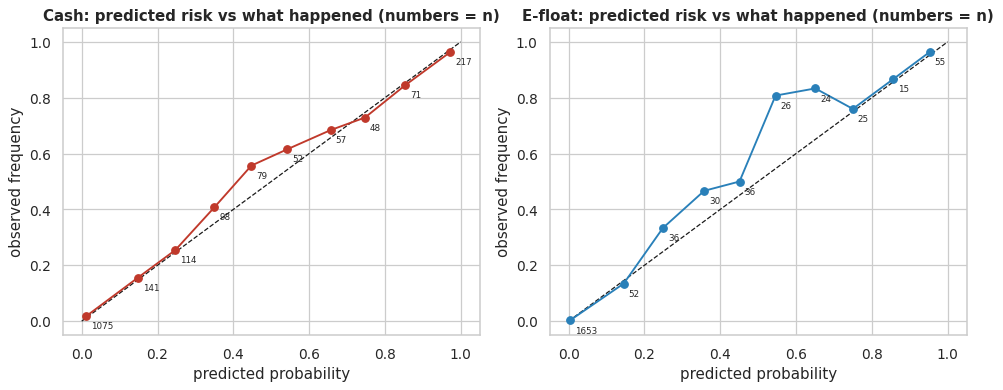

,predicted,observed,n
balance,,,
cash,0.01,0.02,1075
cash,0.19,0.20,255
cash,0.39,0.47,177
cash,0.60,0.65,109
cash,0.81,0.80,119
cash,0.97,0.96,217
e-float,0.00,0.00,1653
e-float,0.19,0.22,88
e-float,0.41,0.48,66


Brier score (lower is better): {'cash': 0.0782, 'e-float': 0.0272}


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a_, (bal, col, nm) in zip(ax, (("cash", "risk_c_w", "Cash"), ("e-float", "risk_e_w", "E-float"))):
    b = pd.cut(R[col], np.linspace(0, 1, 11), include_lowest=True)
    t = pd.DataFrame({"pred": R[col], "obs": lab[bal]}).groupby(b).agg(pred=("pred", "mean"), obs=("obs", "mean"), n=("obs", "size")).dropna()
    a_.plot([0, 1], [0, 1], "k--", lw=1); a_.plot(t.pred, t.obs, "o-", c="#c0392b" if bal == "cash" else "#2980b9")
    for _, r_ in t.iterrows(): a_.annotate(int(r_.n), (r_.pred, r_.obs), textcoords="offset points", xytext=(4, -10), fontsize=7)
    a_.set_title(f"{nm}: predicted risk vs what happened (numbers = n)"); a_.set_xlabel("predicted probability"); a_.set_ylabel("observed frequency")
plt.show()
cal_rows = []
for bal, col in (("cash", "risk_c_w"), ("e-float", "risk_e_w")):
    b = pd.cut(R[col], [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0], include_lowest=True)
    t = pd.DataFrame({"pred": R[col], "obs": lab[bal]}).groupby(b).agg(predicted=("pred", "mean"), observed=("obs", "mean"), n=("obs", "size"))
    cal_rows.append(t.assign(balance=bal).reset_index(drop=True))
display(pd.concat(cal_rows).set_index("balance").style.format({"predicted": "{:.2f}", "observed": "{:.2f}", "n": "{:.0f}"}).set_caption("Reliability table: predicted window risk vs observed breach frequency"))
print("Brier score (lower is better):", {bal: round(brier_score_loss(lab[bal], R[c]), 4) for bal, c in (("cash", "risk_c_w"), ("e-float", "risk_e_w"))})

**Reading this, honestly.**
- The model has a **modest, consistent edge** over both rule-based baselines: ROC-AUC 0.95 vs 0.94 (days-of-cover) vs 0.93 (static) for cash and 0.99 vs 0.98 vs 0.97 for e-float, with a larger gap in PR-AUC (cash 0.89 vs 0.85; e-float 0.88 vs 0.84 and 0.80). The days-of-cover rule is a strong baseline because it uses the same history. The edge is **not** especially larger before long closures in this data (cash 0.93 vs 0.92), so we do not claim that.
- **Calibration** is good at the extremes and slightly under-confident in the middle: a predicted 40% happened 47% of the time for cash (41% → 48% for e-float; the 60% e-float bin → 82%, on only 50 cases). That is consistent with the slightly narrow demand intervals in section 8.
- **The more important result is the blind spot of the habit rule.** 29% of cash breaches (155 of 529) and 32% of e-float breaches (58 of 181) happen while the balance is still **above** the agent's 30% reorder level, where the habit says nothing. At a ≥50% alert threshold the model catches only about a quarter of them; at **≥30% it catches 57% (cash) and 64% (e-float)**, at the price of 84 and 26 false alarms (about 6% and 1.5% of the non-breach cases above the reorder level). The alert threshold is a business dial, and this is its price list.

### 10.2 Worked example: the five outputs for one agent on one day

In [27]:
# Informative examples: the balance is ABOVE the agent's 30% reorder level (so the habit rule stays silent) but the model already sees the problem coming and was right.
cand_c = R[(R.cash0 / R.cap_cash > 0.40) & (R.lab_c_w == 1) & (R.risk_c_w >= 0.6)].sort_values(["W", "risk_c_w"], ascending=False)
cand_e = R[(R.ef0 / R.cap_ef > 0.40) & (R.lab_e_w == 1) & (R.risk_e_w >= 0.6)].sort_values(["W", "risk_e_w"], ascending=False)
ex_c = (cand_c if len(cand_c) else R.sort_values("risk_c_w", ascending=False)).iloc[0]
ex_e = (cand_e if len(cand_e) else R.sort_values("risk_e_w", ascending=False)).iloc[0]

def show(exrow, title):
    g = Te_r[(Te_r.agent_id == exrow.agent_id) & (Te_r.origin_date == exrow.origin_date)].sort_values("h"); ix = g.index.values; r0 = g.iloc[0]
    out = lf.risk_summary(QR["co"][ix], QR["ci"][ix], lf.QUANTILES, r0.cash0, r0.ef0, r0.cap_cash, r0.cap_ef, int(r0.closed_ahead_origin), r0.co_scale, r0.ci_scale, cfg, np.random.default_rng(1))
    days = pd.DataFrame({"date": g.target_date.dt.strftime("%a %d %b").values,
                         "cash-out P10": out["cashout_q"][:, 0], "cash-out median": out["cashout_q"][:, 2], "cash-out P90": out["cashout_q"][:, 4], "P(cash-out surge)": out["p_cashout_surge"],
                         "cash-in P10": out["cashin_q"][:, 0], "cash-in median": out["cashin_q"][:, 2], "cash-in P90": out["cashin_q"][:, 4], "P(cash-in surge)": out["p_cashin_surge"],
                         "cash run-out risk %": out["cash_risk_pct_by_day"], "e-float run-out risk %": out["efloat_risk_pct_by_day"]}).set_index("date")
    print(f"=== {title}: agent {exrow.agent_id} ({loc_type[exrow.agent_id]}, {division[exrow.agent_id]}), forecast from {exrow.origin_date.date()} ===")
    print(f"Balances now: cash ৳{r0.cash0:,.0f} ({r0.cash0/r0.cap_cash:.0%} of nominal capacity ৳{r0.cap_cash:,.0f}) | e-float ৳{r0.ef0:,.0f} ({r0.ef0/r0.cap_ef:.0%} of nominal ৳{r0.cap_ef:,.0f})")
    print(f"1. Cash run-out risk: {out['cash_risk_pct_7d']:.0f}% within 7 days if nothing is done; {out['cash_risk_pct_by_day'][out['coverage_window_days']-1]:.0f}% before the next possible top-up ({out['coverage_window_days']}-day window)"
          + (f"; likely to run out on day {out['likely_cash_runout_day']}" if out["likely_cash_runout_day"] else ""))
    print(f"2. E-float run-out risk: {out['efloat_risk_pct_7d']:.0f}% within 7 days; {out['efloat_risk_pct_by_day'][out['coverage_window_days']-1]:.0f}% within the window"
          + (f"; likely to run out on day {out['likely_efloat_runout_day']}" if out["likely_efloat_runout_day"] else ""))
    print(f"5. Recommended holdings (95% cover for {out['coverage_window_days']} days): cash ≥ ৳{out['recommended_cash_level']:,.0f}, e-float ≥ ৳{out['recommended_efloat_level']:,.0f}"
          f"  →  suggested top-up: cash ৳{out['topup_cash_needed']:,.0f}, e-float ৳{out['topup_efloat_needed']:,.0f}" + ("  [total float too small: needs extra capital]" if out["float_insufficient"] else ""))
    display(days.round(0).style.format("{:,.0f}", subset=[c for c in days.columns if "risk" not in c and "P(" not in c]).format("{:.0%}", subset=[c for c in days.columns if "P(" in c]).format("{:.0f}", subset=[c for c in days.columns if "risk" in c]))
    return out
o1 = show(ex_c, "CASH example (balance above the 30% reorder level, yet the model warns)")
o2 = show(ex_e, "E-FLOAT example (balance above the 30% reorder level, yet the model warns)")

=== CASH example (balance above the 30% reorder level, yet the model warns): agent A01 (garment_urban, Dhaka), forecast from 2025-11-06 ===
Balances now: cash ৳83,130 (46% of nominal capacity ৳180,000) | e-float ৳114,870 (77% of nominal ৳150,000)
1. Cash run-out risk: 99% within 7 days if nothing is done; 90% before the next possible top-up (4-day window); likely to run out on day 3
2. E-float run-out risk: 0% within 7 days; 0% within the window
5. Recommended holdings (95% cover for 4 days): cash ≥ ৳204,543, e-float ≥ ৳23,292  →  suggested top-up: cash ৳121,413, e-float ৳0  [total float too small: needs extra capital]


,cash-out P10,cash-out median,cash-out P90,P(cash-out surge),cash-in P10,cash-in median,cash-in P90,P(cash-in surge),cash run-out risk %,e-float run-out risk %
date,,,,,,,,,,
Fri 07 Nov,"24,755","40,135","42,276",0%,"18,346","23,879","27,665",0%,0,0
Sat 08 Nov,"32,218","61,195","62,614",0%,"24,440","32,533","39,447",0%,0,0
Sun 09 Nov,"43,636","93,198","107,159",100%,"29,050","38,562","50,427",0%,68,0
Mon 10 Nov,"43,766","95,416","108,469",100%,"28,240","39,133","50,171",0%,90,0
Tue 11 Nov,"43,978","61,423","77,973",0%,"29,698","38,534","49,583",0%,95,0
Wed 12 Nov,"43,996","63,856","77,592",0%,"29,536","38,691","50,754",0%,98,0
Thu 13 Nov,"44,047","62,141","79,406",0%,"29,584","37,920","48,947",0%,99,0


=== E-FLOAT example (balance above the 30% reorder level, yet the model warns): agent A03 (market_urban, Chattogram), forecast from 2025-12-24 ===
Balances now: cash ৳114,485 (72% of nominal capacity ৳160,000) | e-float ৳59,515 (46% of nominal ৳130,000)
1. Cash run-out risk: 0% within 7 days if nothing is done; 0% before the next possible top-up (5-day window)
2. E-float run-out risk: 94% within 7 days; 79% within the window; likely to run out on day 4
5. Recommended holdings (95% cover for 5 days): cash ≥ ৳16,412, e-float ≥ ৳117,419  →  suggested top-up: cash ৳0, e-float ৳57,904


,cash-out P10,cash-out median,cash-out P90,P(cash-out surge),cash-in P10,cash-in median,cash-in P90,P(cash-in surge),cash run-out risk %,e-float run-out risk %
date,,,,,,,,,,
Thu 25 Dec,"6,547","8,399","9,914",0%,"10,448","13,444","14,717",0%,0,0
Fri 26 Dec,"19,686","24,455","29,505",0%,"28,252","35,134","46,661",0%,0,0
Sat 27 Dec,"26,393","32,334","38,923",0%,"36,844","49,219","57,338",0%,0,15
Sun 28 Dec,"33,910","46,049","57,915",0%,"43,202","64,890","75,861",0%,0,57
Mon 29 Dec,"33,780","45,548","59,158",0%,"43,238","64,937","73,280",0%,0,79
Tue 30 Dec,"33,226","45,454","57,822",0%,"40,988","63,910","79,541",0%,0,89
Wed 31 Dec,"33,872","45,929","58,573",0%,"43,241","64,587","75,540",0%,0,94


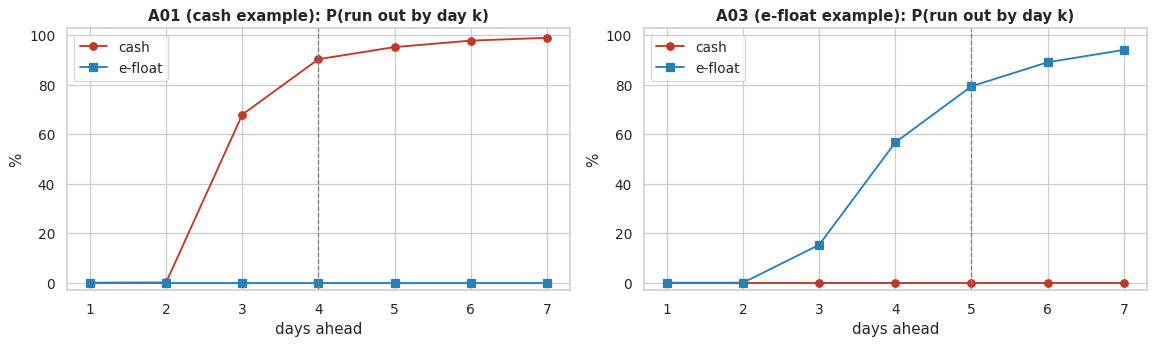

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a_, o, ttl in zip(ax, (o1, o2), (f"{ex_c.agent_id} (cash example)", f"{ex_e.agent_id} (e-float example)")):
    d = np.arange(1, 8); a_.plot(d, o["cash_risk_pct_by_day"], "o-", c="#c0392b", label="cash"); a_.plot(d, o["efloat_risk_pct_by_day"], "s-", c="#2980b9", label="e-float")
    a_.axvline(o["coverage_window_days"], c="grey", ls="--", lw=1); a_.set_ylim(-3, 103); a_.set_title(f"{ttl}: P(run out by day k)"); a_.set_xlabel("days ahead"); a_.set_ylabel("%"); a_.legend()
plt.show()

In the cash example the balance is **above** the agent's 30% reorder level, so the habit rule stays silent while the model already warns, and the recommended holding exceeds the agent's *total* float, so the app also shows "total float too small: needs extra capital". That is a different problem from badly timed top-ups, and section 11 returns to it.

## 11. Business impact: replaying the test period under different top-up policies

Accuracy numbers do not win a hackathon; **stock-outs avoided** do. Because the data is synthetic we can *re-run* the Sep → 24 Dec period with the same true demand, the same distributor calendar (top-ups only on working days, 0 to 1 day lead time) and the same starting balances, changing only **when and how much the agent orders**:

| Policy | Rule |
|---|---|
| **Agent habit** (status quo) | order when a balance < 30% of capacity, top up to 65% |
| **Model only** | order when below the model's recommended level (just-in-time) |
| **Hybrid** (recommended) | trigger and target = **max(habit, model requirement)**: the model only *raises* the safety stock when its forecast says the habit level is not enough (long closures, surges) |

The forecasts used by the model policies are the out-of-sample forecasts from section 7 (trained on data up to July only). Policy parameters were fixed in advance (95% coverage, 10% buffer), not tuned on this window. Caveats: forecasts are held fixed across policies (in reality a policy changes the observed history slightly), and orders are assumed to be always fillable if the other balance can spare the amount.

In [29]:
agent_idx = agents.set_index("agent_id")
def replay(policy, cov=0.95, start="2025-09-01", end="2025-12-24", seed=11, min_order=0.10):
    per = []
    for aid, a in agent_idx.iterrows():
        g = df[df.agent_id == aid].reset_index(drop=True); n = len(g)
        i0, i1 = int(g.index[g.date == start][0]), int(g.index[g.date == end][0])
        work, tco, tci = g.is_working_day.to_numpy(), g.true_cashout_demand.to_numpy(float), g.true_cashin_demand.to_numpy(float)
        cc, ce = a.capacity_cash, a.capacity_efloat
        d2i = {d: i for i, d in enumerate(g.date)}; rq_c, rq_e = np.zeros(n), np.zeros(n)
        for r in R[R.agent_id == aid].itertuples():
            rq_c[d2i[r.origin_date]], rq_e[d2i[r.origin_date]] = r.req_by_cov[cov]
        dly = np.random.default_rng(seed + int(aid[1:])).integers(0, 2, size=(n, 2))      # identical delays for every policy
        cash, ef = float(g.opening_cash[i0]), float(g.opening_efloat[i0]); pc = pe = None
        k = dict(agent_id=aid, cash_so=0, ef_so=0, unserved=0.0, orders=0, moved=0.0, days=i1 - i0 + 1)
        for i in range(i0, i1 + 1):
            if work[i]:
                if pc and i >= pc[0]: amt = min(pc[1], max(0.0, ef - 0.15 * ce)); cash += amt; ef -= amt; k["moved"] += amt; pc = None
                if pe and i >= pe[0]: amt = min(pe[1], max(0.0, cash - 0.15 * cc)); cash -= amt; ef += amt; k["moved"] += amt; pe = None
            sco = sci = 0.0
            for s in range(4):                                      # same 4-slot intraday engine as the generator
                for kind in (("o", "i") if s % 2 == 0 else ("i", "o")):
                    if kind == "o": x = min(tco[i] / 4, cash); cash -= x; ef += x; sco += x
                    else: x = min(tci[i] / 4, ef); ef -= x; cash += x; sci += x
            k["cash_so"] += int(tco[i] - sco > 0.02 * tco[i]); k["ef_so"] += int(tci[i] - sci > 0.02 * tci[i]); k["unserved"] += (tco[i] - sco) + (tci[i] - sci)
            if policy == "habit": trig_c, tgt_c, trig_e, tgt_e = 0.30 * cc, 0.65 * cc, 0.30 * ce, 0.65 * ce
            elif policy == "model_only": trig_c = tgt_c = rq_c[i]; trig_e = tgt_e = rq_e[i]
            else: trig_c, tgt_c, trig_e, tgt_e = max(0.30 * cc, rq_c[i]), max(0.65 * cc, rq_c[i]), max(0.30 * ce, rq_e[i]), max(0.65 * ce, rq_e[i])
            if pc is None and cash < trig_c and (tgt_c - cash) >= (min_order * cc if policy == "model_only" else 0): pc = (i + 1 + dly[i, 0], tgt_c - cash); k["orders"] += 1
            if pe is None and ef < trig_e and (tgt_e - ef) >= (min_order * ce if policy == "model_only" else 0): pe = (i + 1 + dly[i, 1], tgt_e - ef); k["orders"] += 1
        per.append(k)
    return pd.DataFrame(per)

res = {p: replay(p) for p in ("habit", "model_only", "hybrid")}
def tot(d): return pd.Series({"cash stock-out days": d.cash_so.sum(), "e-float stock-out days": d.ef_so.sum(), "% agent-days with a stock-out": 100 * (d.cash_so.sum() + d.ef_so.sum()) / d.days.sum(),
                              "unserved demand (BDT)": d.unserved.sum(), "orders placed": d.orders.sum(), "BDT converted": d.moved.sum()})
T = pd.DataFrame({k: tot(v) for k, v in res.items()}).T
T["Δ stock-out days vs habit"] = (T["cash stock-out days"] + T["e-float stock-out days"]) / (T.loc["habit", "cash stock-out days"] + T.loc["habit", "e-float stock-out days"]) - 1
T["Δ unserved vs habit"] = T["unserved demand (BDT)"] / T.loc["habit", "unserved demand (BDT)"] - 1
T["Δ orders vs habit"] = T["orders placed"] / T.loc["habit", "orders placed"] - 1
display(T.style.format({"cash stock-out days": "{:.0f}", "e-float stock-out days": "{:.0f}", "% agent-days with a stock-out": "{:.2f}", "unserved demand (BDT)": "{:,.0f}", "orders placed": "{:.0f}",
                        "BDT converted": "{:,.0f}", "Δ stock-out days vs habit": "{:+.0%}", "Δ unserved vs habit": "{:+.0%}", "Δ orders vs habit": "{:+.0%}"}))
SUMMARY["policy_replay"] = T.to_dict("index")

,cash stock-out days,e-float stock-out days,% agent-days with a stock-out,unserved demand (BDT),orders placed,BDT converted,Δ stock-out days vs habit,Δ unserved vs habit,Δ orders vs habit
habit,44,20,3.48,"653,720",309,"11,481,396",+0%,+0%,+0%
model_only,52,24,4.13,"549,632",518,"11,492,896",+19%,-16%,+68%
hybrid,19,10,1.58,"232,643",503,"12,225,755",-55%,-64%,+63%


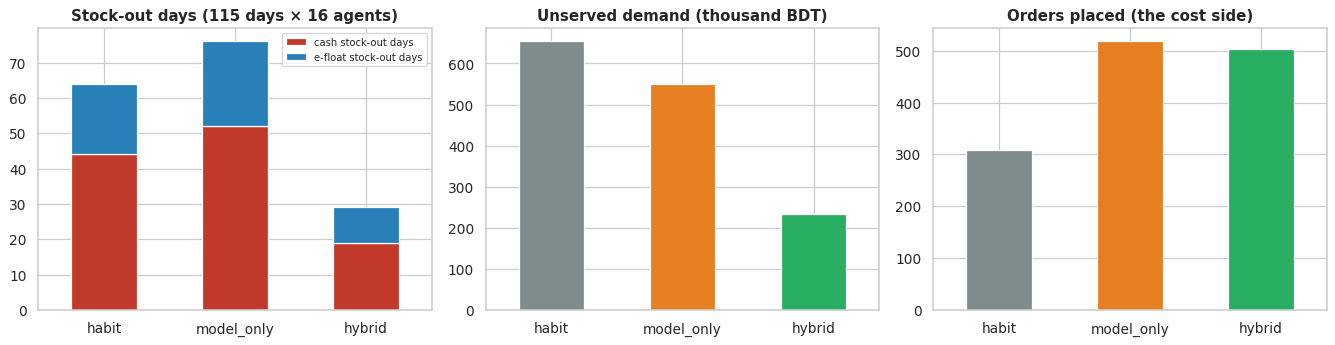

Stock-out days by location type:


,habit,hybrid,reduction
loc,,,
garment_urban,10,8,20%
market_urban,20,10,50%
remittance_urban,4,4,0%
rural,23,5,78%
university_urban,7,2,71%


Capital check: does the agent even HOLD enough total float for the coming window?


,% agent-days where 95% requirement > total float,average shortfall when it happens (BDT)
loc,,
garment_urban,10.7%,"13,062"
market_urban,0.0%,0
remittance_urban,0.0%,0
rural,0.0%,0
university_urban,0.0%,0


In [30]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cols_ = {"habit": "#7f8c8d", "model_only": "#e67e22", "hybrid": "#27ae60"}
T[["cash stock-out days", "e-float stock-out days"]].plot.bar(stacked=True, ax=ax[0], color=["#c0392b", "#2980b9"], rot=0); ax[0].set_title("Stock-out days (115 days × 16 agents)"); ax[0].legend(loc="upper right", fontsize=8)
(T["unserved demand (BDT)"] / 1e3).plot.bar(ax=ax[1], color=[cols_[i] for i in T.index], rot=0); ax[1].set_title("Unserved demand (thousand BDT)")
T["orders placed"].plot.bar(ax=ax[2], color=[cols_[i] for i in T.index], rot=0); ax[2].set_title("Orders placed (the cost side)")
plt.show()
# where does the hybrid win? by agent type
bt_ = pd.DataFrame({p: res[p].assign(loc=res[p].agent_id.map(loc_type)).groupby("loc").apply(lambda d: d.cash_so.sum() + d.ef_so.sum()) for p in ("habit", "hybrid")})
bt_["reduction"] = 1 - bt_.hybrid / bt_.habit; print("Stock-out days by location type:"); display(bt_.style.format({"reduction": "{:.0%}"}))

# Where the hybrid cannot help: the agent's TOTAL float (cash + e-float) is smaller than what the coming window needs. No re-allocation fixes that; it needs more capital.
R["loc"] = R.agent_id.map(loc_type)
fs = R.groupby("loc").apply(lambda d: pd.Series({"% agent-days where 95% requirement > total float": 100 * (d.float_gap > 0).mean(),
                                                  "average shortfall when it happens (BDT)": d.float_gap[d.float_gap > 0].mean() if (d.float_gap > 0).any() else 0.0}))
print("Capital check: does the agent even HOLD enough total float for the coming window?"); display(fs.style.format({"% agent-days where 95% requirement > total float": "{:.1f}%", "average shortfall when it happens (BDT)": "{:,.0f}"}))
SUMMARY["float_shortfall_by_type"] = fs.to_dict("index")

### 11.1 The cost/benefit curve: how much safety is worth buying?

The coverage level is a business dial, not a statistical fact. A higher level means fewer stock-outs but more orders (trips) and more capital sitting in the drawer. We show the whole curve rather than only the best-looking point.

,total stock-out days,unserved demand (BDT),orders placed,BDT converted
habit (status quo),64,"653,720",309,"11,481,396"
"hybrid, 80% coverage",40,"380,811",396,"11,926,096"
"hybrid, 90% coverage",36,"373,533",450,"12,019,242"
"hybrid, 95% coverage",29,"232,643",503,"12,225,755"
"hybrid, 99% coverage",18,"212,064",587,"12,315,078"


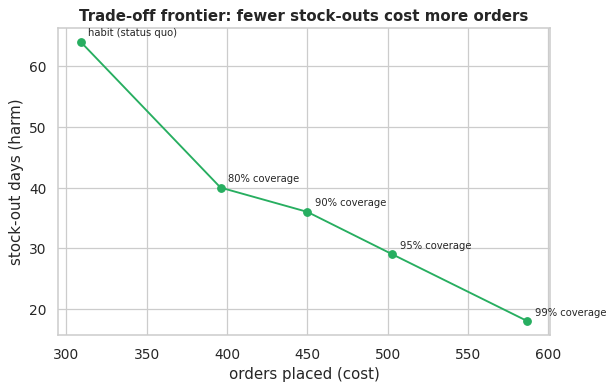

In [31]:
sweep = {"habit (status quo)": tot(res["habit"])}
for c in COVS: sweep[f"hybrid, {int(c*100)}% coverage"] = tot(replay("hybrid", cov=c))
S = pd.DataFrame(sweep).T; S["total stock-out days"] = S["cash stock-out days"] + S["e-float stock-out days"]
display(S[["total stock-out days", "unserved demand (BDT)", "orders placed", "BDT converted"]].style.format({"total stock-out days": "{:.0f}", "unserved demand (BDT)": "{:,.0f}", "orders placed": "{:.0f}", "BDT converted": "{:,.0f}"}))
SUMMARY["coverage_sweep"] = S[["total stock-out days", "unserved demand (BDT)", "orders placed"]].to_dict("index")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(S["orders placed"], S["total stock-out days"], "o-", c="#27ae60")
for n_, r_ in S.iterrows(): ax.annotate(n_.replace("hybrid, ", ""), (r_["orders placed"], r_["total stock-out days"]), textcoords="offset points", xytext=(6, 5), fontsize=8)
ax.set_xlabel("orders placed (cost)"); ax.set_ylabel("stock-out days (harm)"); ax.set_title("Trade-off frontier: fewer stock-outs cost more orders"); plt.show()

**Reading this honestly.**
- The **hybrid** policy cuts stock-out days from 64 to 29 (−55%) and unserved demand from ৳654k to ৳233k (−64%) over 115 days × 16 agents. The **model-only** (just-in-time) policy does *not* reduce stock-outs (76 days, +19%) despite placing 68% more orders: the habit's generous 65% target is a better buffer than a tight statistical minimum. The model's value is knowing **when the habit buffer is not enough**, not replacing it.
- It is **not free**: the hybrid places 63% more orders (309 → 503). Whether that is worth it depends on the cost of a trip versus an unserved customer, which only upay can quantify. The frontier above gives the menu (80% coverage: 40 days / 396 orders; 95%: 29 / 503; 99%: 18 / 587).
- **Agent types benefit unequally.** Rural (−78%), university (−71%) and market (−50%) agents improve most; remittance-urban does not change (4 → 4 days, one agent, small numbers) and garment improves only 20% (10 → 8). The capital check explains the garment case: on 10.7% of its agent-days the 95% requirement exceeds the agent's **total** float, by about ৳13k on average. No re-allocation between cash and e-float can fix that; **the right advice there is more capital**, which the app flags (`float_insufficient`).
- This is a simulation on synthetic demand with fixed forecasts. It shows the mechanism works; a pilot on real data (rulebook stages 4–5) would measure the real effect.

## 12. Final model: retrain on all data and export the `.pkl`

Everything above used the train-only model so the test numbers are honest. For the deployable model we **retrain on all 365 days**, using the tree counts found by early stopping (+10% for the extra data). The saved bundle contains the 10 quantile models, the feature list, the risk configuration (so the business can change buffers without retraining), the calendar configuration, the agent table, and the evaluation summary.

In [32]:
rounds = {k: int(v * 1.1) + 1 for k, v in best_iter.items()}
p1_rounds = {f: int(p1_best[f] * 1.1) + 1 for f in ("co", "ci")}
final_models, _ = fit_models(F, pd.Series(True, index=F.index), None, rounds=rounds, p1_rounds=p1_rounds)      # same censoring-aware recipe, all 365 days
bundle = {
    "name": "agent-liquidity-forecaster", "version": "1.0.0", "created": pd.Timestamp.now().isoformat(timespec="seconds"),
    "models": final_models, "feature_cols": cols, "quantiles": lf.QUANTILES, "horizon": lf.H,
    "risk_config": lf.DEFAULT_RISK_CONFIG, "calendar_config": lf.DEFAULT_CALENDAR_CONFIG, "agents": agents,
    "trained_on": {"rows": int(len(F)), "agents": int(df.agent_id.nunique()), "dates": f"{df.date.min().date()} to {df.date.max().date()}", "data": "synthetic (generate_dataset_v2.py)"},
    "eval_summary": SUMMARY,
    "library_versions": {"lightgbm": lgb.__version__, "pandas": pd.__version__, "numpy": np.__version__},   # pickled boosters can be version-sensitive
    "notes": ["Demand model is balance-independent; balances enter only through the Monte Carlo roll-forward.",
              "Trained with censoring-aware labels: on stock-out days the observed demand is replaced by max(observed, pass-1 P75 forecast). Needs a stock-out signal in production data.",
              "Targets are relative to each agent's 28-day mean; predictions are multiplied back by liquidity_forecaster.make_features()['co_scale'/'ci_scale'].",
              "Trained on SYNTHETIC data: validates the pipeline, not real-world accuracy. Re-validate on governed upay data before any pilot.",
              "Calendar config covers 2025 only; extend lf.DEFAULT_CALENDAR_CONFIG for later years.",
              "Needs >= 28 days of daily history per agent. Use liquidity_forecaster.forecast_agent() for serving."],
}
PKL = Path("liquidity_model_bundle.pkl")
with open(PKL, "wb") as f: pickle.dump(bundle, f, protocol=4)
print(f"Saved {PKL} ({PKL.stat().st_size/1e6:.2f} MB): {sum(len(v) for v in final_models.values())} LightGBM boosters, "
      f"{sum(b.num_trees() for m in final_models.values() for b in m.values()):,} trees in total")

Saved liquidity_model_bundle.pkl (4.90 MB): 10 LightGBM boosters, 3,152 trees in total


### 12.1 Serving test: reload the `.pkl` and prove train/serve consistency

Two things must hold before this file goes anywhere near an API: (1) a freshly loaded pickle gives **identical** results to the in-memory model, and (2) the **serving path** (which builds future calendar rows itself, with no future data) reproduces the **training path**'s predictions exactly. If (2) fails, the live app would silently disagree with the evaluation above.

In [33]:
with open(PKL, "rb") as f: loaded = pickle.load(f)
aid, origin = "A01", pd.Timestamp("2025-12-10")
g = df[df.agent_id == aid]; st = g[g.date == origin].iloc[0]; arow = lf.get_agent_row(loaded, aid)
hist = g[g.date <= origin][["date", "observed_cashout", "observed_cashin"]]                           # history ONLY: no future rows are given to the serving function
srv = lf.forecast_agent(loaded, hist, arow, origin, st.closing_cash, st.closing_efloat, seed=5)
srv_mem = lf.forecast_agent(bundle, hist, arow, origin, st.closing_cash, st.closing_efloat, seed=5)
assert np.allclose(srv["cashout_q"], srv_mem["cashout_q"]) and np.allclose(srv["expected_cashout"], srv_mem["expected_cashout"])
print("(1) reloaded pickle == in-memory model: OK")
f_row = F[(F.agent_id == aid) & (F.origin_date == origin)].sort_values("h")
train_path = lf.predict_quantiles(loaded, f_row)
assert np.allclose(train_path["co"], srv["cashout_q"]) and np.allclose(train_path["ci"], srv["cashin_q"])
print("(2) serving path (builds its own future calendar) == training path: OK")
print(f"\nServing output for {aid} on {origin.date()}: cash risk {srv['cash_risk_pct_7d']:.0f}% (7d), recommended cash level ৳{srv['recommended_cash_level']:,.0f}, suggested cash top-up ৳{srv['topup_cash_needed']:,.0f}")

(1) reloaded pickle == in-memory model: OK
(2) serving path (builds its own future calendar) == training path: OK

Serving output for A01 on 2025-12-10: cash risk 100% (7d), recommended cash level ৳78,532, suggested cash top-up ৳56,130


## 13. Results at a glance

In [34]:
w = SUMMARY["wape_test"]; pr = SUMMARY["policy_replay"]
glance = pd.Series({
    "Cash-out WAPE (model | same-weekday baseline)": f"{w['Cash-out']['WAPE model']:.3f} | {w['Cash-out']['WAPE same-weekday-last-week']:.3f}",
    "Cash-in WAPE (model | same-weekday baseline)": f"{w['Cash-in']['WAPE model']:.3f} | {w['Cash-in']['WAPE same-weekday-last-week']:.3f}",
    "Irreducible noise floor (WAPE)": f"{SUMMARY['noise_floor_wape']:.3f}",
    "80% interval coverage (cash-out | cash-in)": f"{SUMMARY['interval_80_coverage']['co']:.1%} | {SUMMARY['interval_80_coverage']['ci']:.1%}",
    "Stock-out days, habit → hybrid": f"{pr['habit']['cash stock-out days']+pr['habit']['e-float stock-out days']:.0f} → {pr['hybrid']['cash stock-out days']+pr['hybrid']['e-float stock-out days']:.0f}",
    "Unserved demand, habit → hybrid (BDT)": f"{pr['habit']['unserved demand (BDT)']:,.0f} → {pr['hybrid']['unserved demand (BDT)']:,.0f}",
    "Orders placed, habit → hybrid": f"{pr['habit']['orders placed']:.0f} → {pr['hybrid']['orders placed']:.0f}",
}); display(glance.to_frame("test period (Sep–Dec 2025)"))

,test period (Sep–Dec 2025)
Cash-out WAPE (model | same-weekday baseline),0.171 | 0.315
Cash-in WAPE (model | same-weekday baseline),0.175 | 0.303
Irreducible noise floor (WAPE),0.161
80% interval coverage (cash-out | cash-in),77.0% | 75.3%
"Stock-out days, habit → hybrid",64 → 29
"Unserved demand, habit → hybrid (BDT)","653,720 → 232,643"
"Orders placed, habit → hybrid",309 → 503


### Key findings
1. **Accuracy.** WAPE 0.171 / 0.175 (cash-out / cash-in) against 0.315 / 0.303 for the same-weekday baseline, close to the 0.161 noise floor of the synthetic data.
2. **One accuracy number hid a serious bias.** The first model under-predicted garment payday demand by 38%. Interaction features plus **censoring-aware labels** brought it to about 0%, matching an oracle trained on true demand.
3. **Risk scores** beat rule-based baselines modestly and are reasonably calibrated; their real value is catching breaches the 30%-reorder habit misses (57–64% of them at a ≥30% alert threshold).
4. **Policy replay.** A hybrid (habit buffer raised by the model's requirement) cuts stock-out days 55% and unserved demand 64% for 63% more orders. A pure model-driven policy does not work. Some agents need capital, not better forecasts.
5. **Generalisation.** A never-seen agent is forecast about as well as a seen one; a never-seen *festival* only partially (one Eid is thin evidence).

*Numbers in the commentary are quoted from the executed run stored in this notebook; re-running may change the last digit.*

## 14. Limitations (state these in the pitch before a judge finds them)

1. **Synthetic data.** The model recovers patterns *we planted*. Test accuracy proves the pipeline works end to end; it does not predict real-world accuracy. The path forward is the rulebook's own: controlled validation on governed upay data.
2. **One year, no Eid in the test period.** The festival effect is tested by a blocked hold-out (section 9a), which is weaker than a true out-of-time test. A second year of data would fix this.
3. **Censoring.** Observed demand is only a floor on stock-out days. Section 7.1 shows this biased payday demand by as much as -38% before the fix; the censoring-aware labels remove most of it, but they rely on a reliable stock-out signal, which real data must provide (declined transactions, balance-zero events).
4. **Independence assumption.** The Monte Carlo samples days and the two flows independently. Real demand shocks are correlated across days (a rainy week), so tail risk is probably *understated*. The slightly narrow intervals (section 8) point the same way. For the same reason the flat error-by-horizon curve is an artifact of independent noise in the generator, not a property real data would share.
5. **Policy replay is a simulation** with forecasts held fixed and idealized order filling. It shows the mechanism, not a measured business result.
6. **Cash self-reports** can be wrong; the reconciliation flag is an app-level rule, not part of this model.
7. **Calendar covers 2025 only**, and moon-dependent dates (Eid, Ashura) can shift by a day; an admin-editable events table (planned in the app) is the right long-term source.

## 15. How this maps to the rulebook

| Rulebook requirement | Where it is addressed |
|---|---|
| Clear user, problem, measurable impact | Agents/admins; stock-out days and unserved demand (section 11) |
| AI beats a simple rule | Days-of-cover and static baselines (10.1); policy replay (11) |
| Synthetic data, documented assumptions, clean test set | Generator docstring; chronological split (6) |
| Explainability | tree-SHAP drivers in taka (8.1) |
| Fairness check | error by location type (8) |
| Business rules separate from ML | `risk_config` and the Monte Carlo layer, outside the model (10) |
| Human oversight / no autonomous financial decisions | Output is a recommendation; agent or admin decides |
| Path to real data | Re-validation plan, API-shaped `forecast_agent()` (12.1, 14) |